# Neural Data Science 970405 -- Final Project: Submission Notebook

**Team:** Daniel Katz, Rona Lavi, Sophia Danilov &mdash; Technion Spring 2026.

Companion code notebook for `final.md`. Each section below reproduces one figure referenced in the report. Shared analysis logic (dataset loading, phase detection, covariance/diffusion-map geometry, classifiers) is imported from the project's library modules, not re-derived.

---

We address our research question in **four steps**:

| Step | Description | Cells |
|------|-------------|-------|
| **1** | Characterizing the dataset and its PRE / SOCIAL / POST structure | 1.1 -- 1.2 |
| **2** | PRE-vs-SOCIAL classifier on **mean firing rate**, scored on held-out POST | 2.1 -- 2.6 |
| **3** | **Diffusion-map clustering** of population covariance structure | 3.1 -- 3.3 |
| **4** | Same classifier on **covariance-geometry** (Riemannian tangent-space) features, scored on POST | 4.1 |

> Steps 2 and 4 share the same classifier pipeline (L2 logistic regression, block-CV); only the feature representation differs. The main results cell (2.1 / 4.1) generates both figures in a single loop.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import scipy.io as sio

%matplotlib inline

# Resolve the repo root from the notebook's working directory.
REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "Main" / "gui").is_dir():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from Main.gui import covariance_viz, data_loading as dl, features as feat_mod

DATA_DIR = str(REPO_ROOT / "Data")
FIG_DIR = Path.cwd().resolve() / "figures_submission"
RESULTS_DIR = REPO_ROOT / "Main" / "gui" / "results"

# Canonical windowing convention used throughout (see final.md Methods).
GUARD_S, WIN_S, STEP_S, LAM_SCALE = 10.0, 10.0, 5.0, 0.1
MICE = ["M2", "M3", "M6", "M7", "M8"]
PHASE_COLORS = {"pre": "#4ea8de", "social": "#ff6b6b", "post": "#a8e6cf"}

print("repo root:", REPO_ROOT)
print("data dir :", DATA_DIR, "exists:", Path(DATA_DIR).is_dir())

repo root: C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project
data dir : C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Data exists: True


---
# Step 1: Characterizing the dataset and PRE / SOCIAL / POST structure

## 1.1 Dataset overview (Fig. 1)

33 sessions, 5 mice (M2, M3, M6, M7, M8), PRE / SOCIAL / POST paradigm. Phase boundaries come from DLC `frameIndex` backward-resets via `dl.load_dataset` / `dl.load_session_record`.

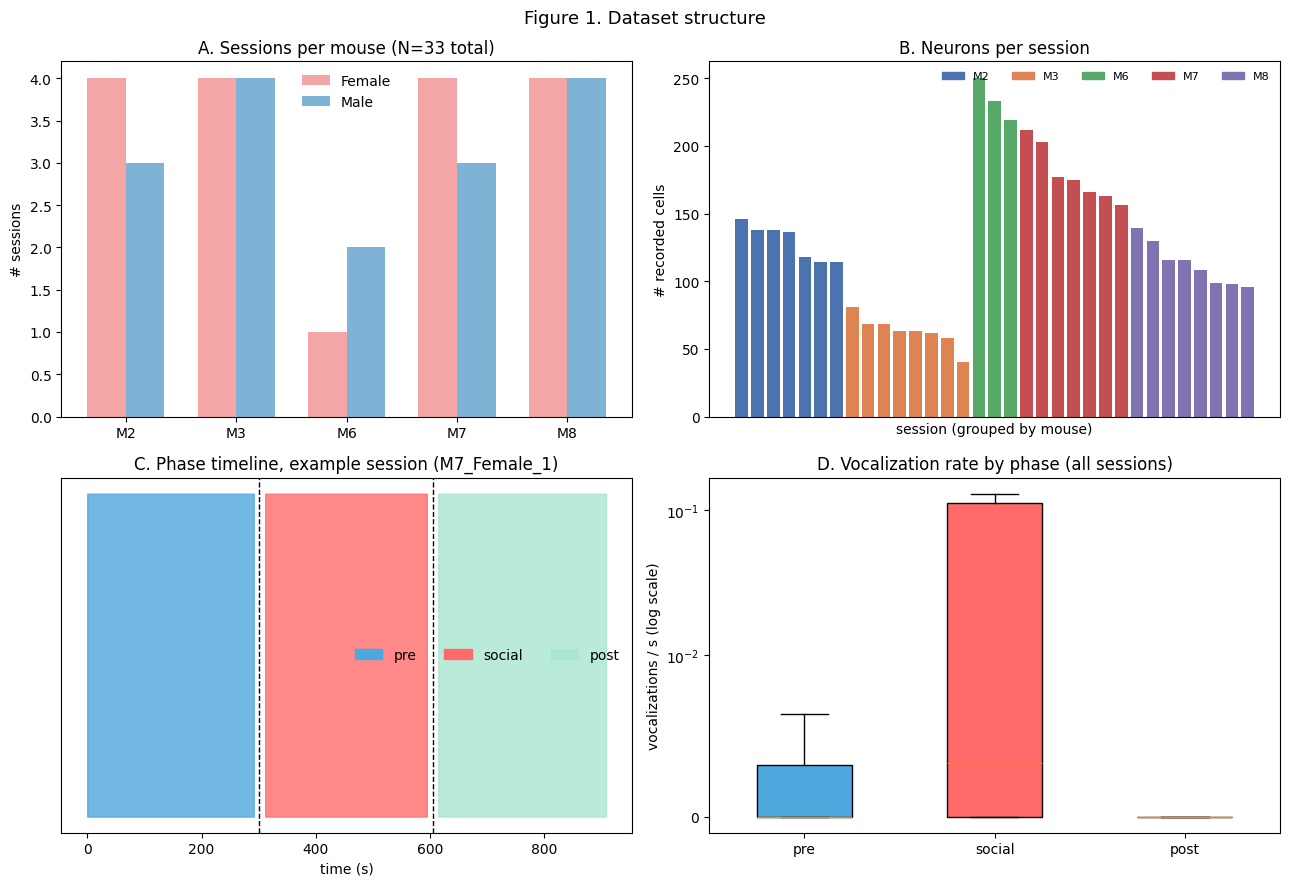

In [2]:
MOUSE_COLORS = {"M2": "#4c72b0", "M3": "#dd8452", "M6": "#55a868", "M7": "#c44e52", "M8": "#8172b2"}
EXAMPLE_SESSION = "M7_Female_1"

per_mouse = dl.load_dataset(mice=MICE, guard_s=GUARD_S, data_dir=DATA_DIR)
rows = []
for mouse, recs in per_mouse.items():
    for rec in recs:
        # vocalizationTimes isn't carried by load_session_record -- pull it directly, same field
        # the rest of the pipeline reads with np.atleast_1d.
        m = sio.loadmat(str(Path(DATA_DIR) / f"{rec['session']}.mat"), simplify_cells=True)
        vocs = np.atleast_1d(m["data"].get("vocalizationTimes", np.array([])))
        vocs = vocs[np.isfinite(vocs)] if len(vocs) else vocs
        t, t_in, t_out = rec["t"], rec["t_in"], rec["t_out"]
        rates = [np.sum(vocs < t_in) / max(t_in, 1),
                 np.sum((vocs >= t_in) & (vocs <= t_out)) / max(t_out - t_in, 1),
                 np.sum(vocs > t_out) / max(t[-1] - t_out, 1)]
        rows.append(dict(session=rec["session"], mouse=mouse, stim=rec["stim"], n_cells=rec["n_cells"],
                          t=t, phase=rec["phase"], t_in=t_in, t_out=t_out, voc_rates=rates))

mice_present = sorted(per_mouse)
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# A. sessions per mouse x stimulus
ax = axes[0, 0]
x = np.arange(len(mice_present))
for i, stim in enumerate(["Female", "Male"]):
    counts = [sum(1 for r in rows if r["mouse"] == mo and r["stim"] == stim) for mo in mice_present]
    ax.bar(x + (i - 0.5) * 0.35, counts, 0.35, label=stim, color="#f4a6a6" if stim == "Female" else "#7fb3d5")
ax.set_xticks(x); ax.set_xticklabels(mice_present)
ax.set_ylabel("# sessions"); ax.set_title(f"A. Sessions per mouse (N={len(rows)} total)")
ax.legend(frameon=False)

# B. cells per session, colored by mouse
ax = axes[0, 1]
rows_sorted = sorted(rows, key=lambda r: (r["mouse"], -r["n_cells"]))
ax.bar(range(len(rows_sorted)), [r["n_cells"] for r in rows_sorted],
       color=[MOUSE_COLORS[r["mouse"]] for r in rows_sorted])
ax.set_xlabel("session (grouped by mouse)"); ax.set_ylabel("# recorded cells")
ax.set_title("B. Neurons per session"); ax.set_xticks([])
ax.legend([plt.Rectangle((0, 0), 1, 1, color=MOUSE_COLORS[mo]) for mo in mice_present], mice_present,
          frameon=False, ncol=len(mice_present), fontsize=8)

# C. example session timeline
ax = axes[1, 0]
ex = next(r for r in rows if r["session"] == EXAMPLE_SESSION)
names = {0: "pre", 1: "social", 2: "post"}
for code, name in names.items():
    ax.fill_between(ex["t"], 0, 1, where=ex["phase"] == code, color=PHASE_COLORS[name], alpha=0.8, step="mid")
ax.axvline(ex["t_in"], color="k", ls="--", lw=1); ax.axvline(ex["t_out"], color="k", ls="--", lw=1)
ax.set_yticks([]); ax.set_xlabel("time (s)")
ax.set_title(f"C. Phase timeline, example session ({EXAMPLE_SESSION})")
ax.legend([plt.Rectangle((0, 0), 1, 1, color=PHASE_COLORS[n]) for n in names.values()], list(names.values()),
          frameon=False, ncol=3)

# D. vocalization rate by phase
ax = axes[1, 1]
rates = np.array([r["voc_rates"] for r in rows])
bp = ax.boxplot([rates[:, 0], rates[:, 1], rates[:, 2]], positions=[0, 1, 2], widths=0.5,
                patch_artist=True, showfliers=False)
for patch, name in zip(bp["boxes"], names.values()):
    patch.set_facecolor(PHASE_COLORS[name])
ax.set_yscale("symlog", linthresh=0.01)
ax.set_xticks([0, 1, 2]); ax.set_xticklabels(list(names.values()))
ax.set_ylabel("vocalizations / s (log scale)"); ax.set_title("D. Vocalization rate by phase (all sessions)")

fig.suptitle("Figure 1. Dataset structure", fontsize=13)
fig.tight_layout()
# Inline display only -- does not overwrite the saved report figure.
plt.show()

## 1.2 Cross-validation scheme

Illustrative/synthetic diagram (no session data needed): sliding overlapping windows, shuffled block-CV with adjacent-window purging, POST held out entirely. Reproduces the CV schematic figure.

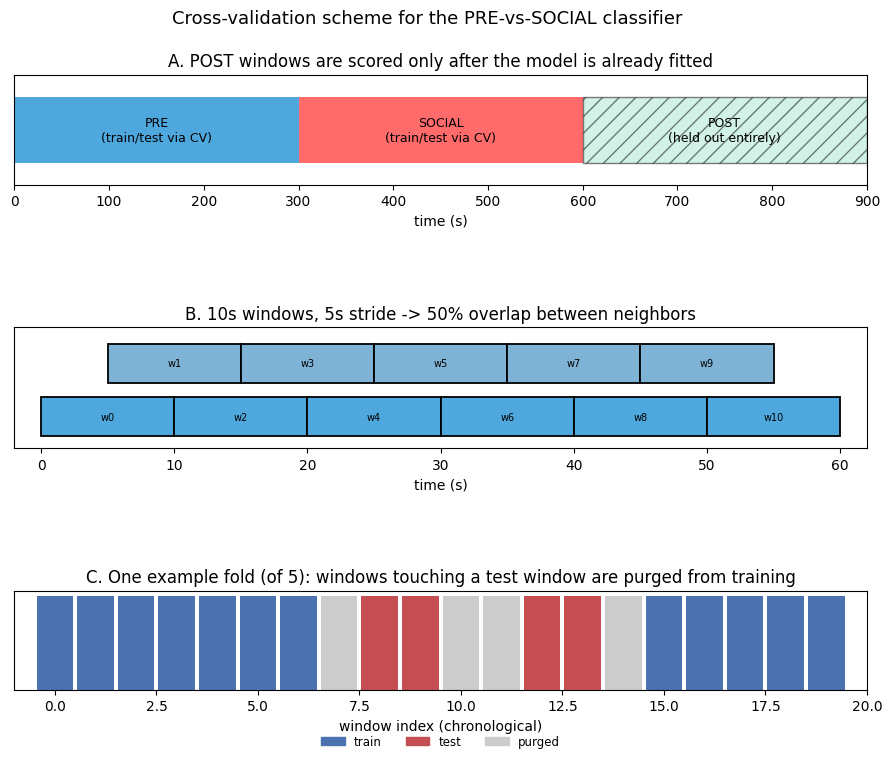

In [3]:
PRE_S = SOCIAL_S = POST_S = 300.0

fig, axes = plt.subplots(3, 1, figsize=(11, 8.2), height_ratios=[1, 1.1, 0.9])

# A. whole-trial timeline
ax = axes[0]
ax.barh(0, PRE_S, height=0.6, color="#4ea8de")
ax.barh(0, SOCIAL_S, left=PRE_S, height=0.6, color="#ff6b6b")
ax.barh(0, POST_S, left=PRE_S + SOCIAL_S, height=0.6, color="#a8e6cf", edgecolor="black", hatch="//", alpha=0.5)
ax.text(PRE_S / 2, 0, "PRE\n(train/test via CV)", ha="center", va="center", fontsize=9)
ax.text(PRE_S + SOCIAL_S / 2, 0, "SOCIAL\n(train/test via CV)", ha="center", va="center", fontsize=9)
ax.text(PRE_S + SOCIAL_S + POST_S / 2, 0, "POST\n(held out entirely)", ha="center", va="center", fontsize=9)
ax.set_xlim(0, PRE_S + SOCIAL_S + POST_S); ax.set_ylim(-0.5, 0.5); ax.set_yticks([])
ax.set_xlabel("time (s)"); ax.set_title("A. POST windows are scored only after the model is already fitted")

# B. sliding overlapping windows
ax = axes[1]
starts = np.arange(0, 60 - WIN_S + 1e-9, STEP_S)
for i, s in enumerate(starts):
    y = 0.22 * (i % 2)
    ax.add_patch(plt.Rectangle((s, y), WIN_S, 0.16, facecolor="#4ea8de" if i % 2 == 0 else "#7fb3d5",
                                edgecolor="black", linewidth=1.3))
    ax.text(s + WIN_S / 2, y + 0.08, f"w{i}", ha="center", va="center", fontsize=7)
ax.set_xlim(-2, 62); ax.set_ylim(-0.05, 0.45); ax.set_yticks([]); ax.set_xlabel("time (s)")
ax.set_title(f"B. {WIN_S:.0f}s windows, {STEP_S:.0f}s stride -> 50% overlap between neighbors")

# C. shuffled block-CV, one example fold
ax = axes[2]
n_windows = 20
rng = np.random.default_rng(0)
shuffled = rng.permutation(np.arange(n_windows // 2))
test_idx = {2 * b + k for b in shuffled[:2] for k in (0, 1)}
purge_idx = ({i - 1 for i in test_idx} | {i + 1 for i in test_idx}) - test_idx
purge_idx = {i for i in purge_idx if 0 <= i < n_windows}
colors = {"train": "#4c72b0", "test": "#c44e52", "purged": "#cccccc"}
for i in range(n_windows):
    kind = "test" if i in test_idx else ("purged" if i in purge_idx else "train")
    ax.bar(i, 1, width=0.9, color=colors[kind])
ax.legend([plt.Rectangle((0, 0), 1, 1, color=colors[k]) for k in colors], list(colors),
          loc="lower center", bbox_to_anchor=(0.5, -0.7), ncol=3, frameon=False, fontsize=8.5)
ax.set_xlim(-1, n_windows); ax.set_yticks([]); ax.set_xlabel("window index (chronological)")
ax.set_title("C. One example fold (of 5): windows touching a test window are purged from training")

fig.suptitle("Cross-validation scheme for the PRE-vs-SOCIAL classifier", fontsize=13)
fig.subplots_adjust(hspace=1.3, top=0.90, bottom=0.15)
# Inline display only -- does not overwrite the saved report figure.
plt.show()

---
# Step 2: PRE-vs-SOCIAL classifier on mean firing rate, scored on POST
# Step 4: Same classifier on covariance-geometry features, scored on POST

## 2.1 / 4.1 Classifier results -- pooled across all 33 sessions (Figs. 2 & 4)

Both feature representations (mean firing rate &rarr; Fig. 2; covariance-geometry tangent-space &rarr; Fig. 4) are generated in one loop below, loading pre-computed results. Colored by stimulus sex (Female = red tones, Male = blue tones).

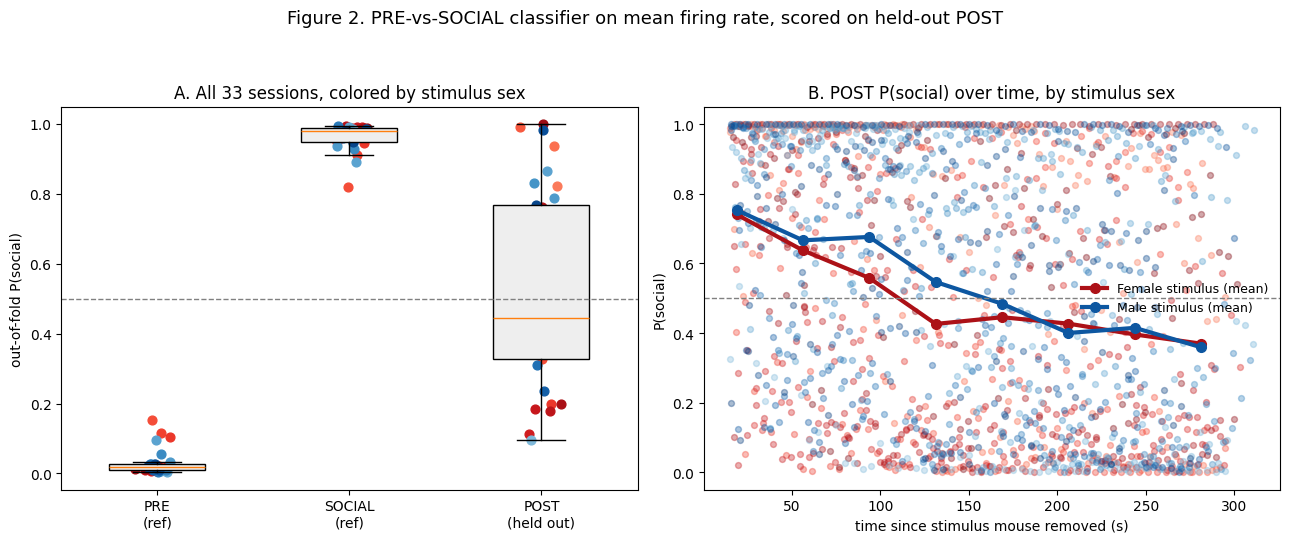

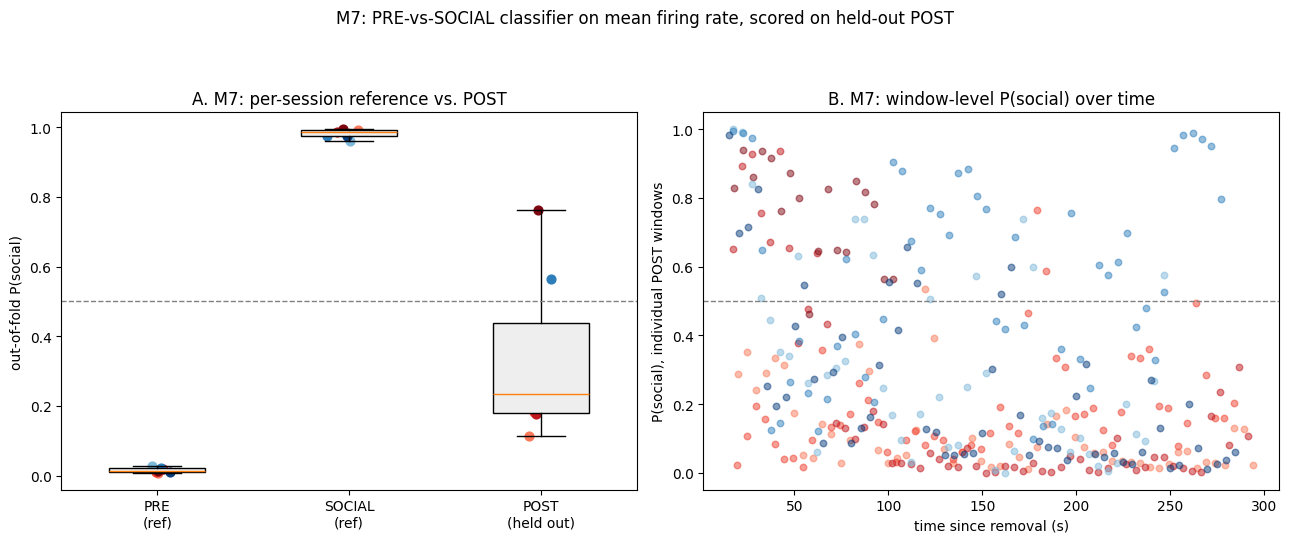

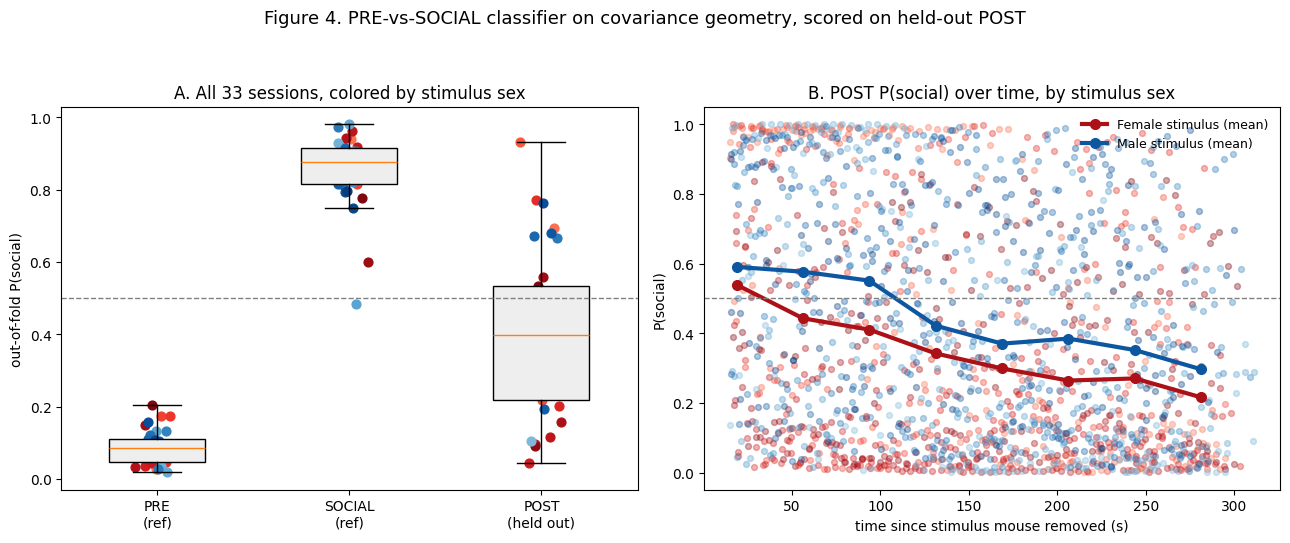

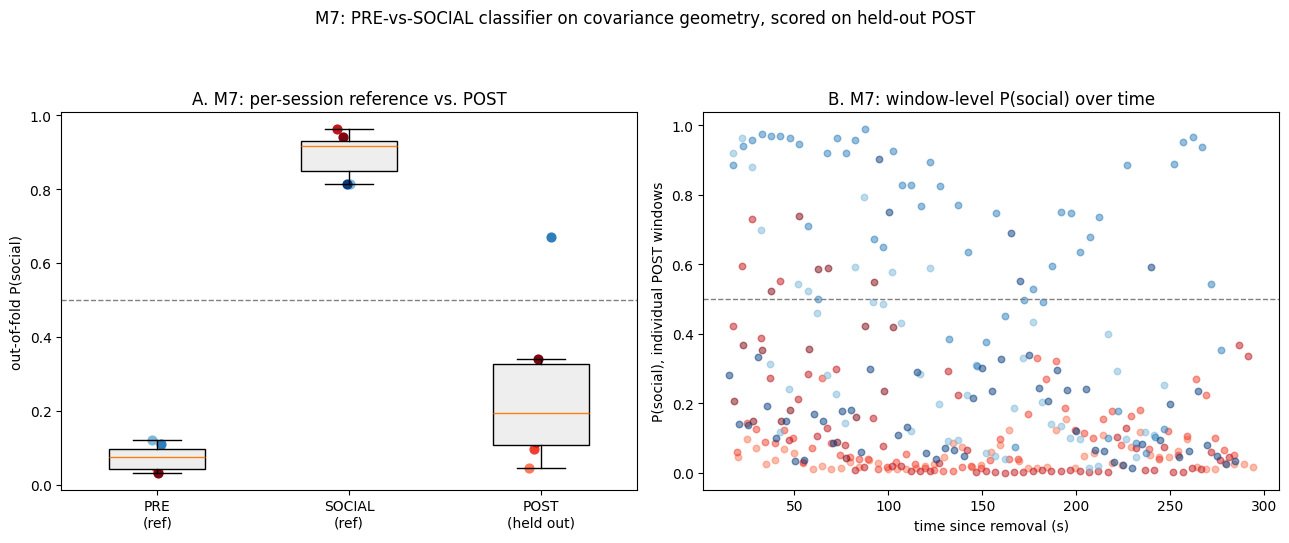

In [4]:
RUNS = [
    (RESULTS_DIR / "20260915T192205_176364b7.json", "mean firing rate", "fig2_classifier_mean_rate", 2),
    (RESULTS_DIR / "20260915T203718_9ce7c4f8.json", "covariance geometry", "fig4_classifier_covariance", 4),
]
FEMALE_CMAP, MALE_CMAP = plt.get_cmap("Reds"), plt.get_cmap("Blues")


def shade(stim, idx, n):
    cmap = FEMALE_CMAP if stim == "Female" else MALE_CMAP
    return cmap(0.45 + 0.5 * (idx / max(n - 1, 1)))


def pooled_figure(sessions, feature_label, fig_num):
    """Reproduces fig2/fig4 as they appear in final.md: pooled across all 33 sessions, colored by
    stimulus sex. """
    by_stim = {"Female": [], "Male": []}
    for s in sessions:
        by_stim.setdefault(s["stim"], []).append(s)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

    ax = axes[0]
    groups = [[s["checkpoint"][k] for s in sessions]
              for k in ("pre_ref_mean", "social_ref_mean", "mean_p_social")]
    bp = ax.boxplot(groups, positions=[0, 1, 2], widths=0.5, patch_artist=True, showfliers=False)
    for patch in bp["boxes"]:
        patch.set_facecolor("#eeeeee")
    rng = np.random.default_rng(0)
    for i, key in enumerate(["pre_ref_mean", "social_ref_mean", "mean_p_social"]):
        for stim, group in by_stim.items():
            for j, s in enumerate(group):
                ax.scatter(i + rng.normal(0, 0.05), s["checkpoint"][key], color=shade(stim, j, len(group)), s=40)
    ax.axhline(0.5, color="grey", ls="--", lw=1)
    ax.set_xticks([0, 1, 2]); ax.set_xticklabels(["PRE\n(ref)", "SOCIAL\n(ref)", "POST\n(held out)"])
    ax.set_ylabel("out-of-fold P(social)"); ax.set_title("A. All 33 sessions, colored by stimulus sex")

    ax = axes[1]
    for stim, group in by_stim.items():
        since_all, p_all = [], []
        for j, s in enumerate(group):
            pts = s["checkpoint"].get("points", [])
            if pts:
                since_all.extend(p["t_since"] for p in pts)
                p_all.extend(p["p_social"] for p in pts)
                ax.scatter([p["t_since"] for p in pts], [p["p_social"] for p in pts],
                           color=shade(stim, j, len(group)), alpha=0.35, s=18)
        since_all, p_all = np.array(since_all), np.array(p_all)
        if len(since_all) > 5:
            bins = np.linspace(0, 300, 9)
            bin_idx = np.digitize(since_all, bins) - 1
            bc = [(bins[b] + bins[b + 1]) / 2 for b in range(len(bins) - 1) if (bin_idx == b).sum() > 0]
            bm = [p_all[bin_idx == b].mean() for b in range(len(bins) - 1) if (bin_idx == b).sum() > 0]
            line_color = FEMALE_CMAP(0.85) if stim == "Female" else MALE_CMAP(0.85)
            ax.plot(bc, bm, color=line_color, lw=3, marker="o", ms=7, label=f"{stim} stimulus (mean)")
    ax.axhline(0.5, color="grey", ls="--", lw=1)
    ax.set_xlabel("time since stimulus mouse removed (s)"); ax.set_ylabel("P(social)")
    ax.set_title("B. POST P(social) over time, by stimulus sex"); ax.legend(fontsize=9, frameon=False)

    fig.suptitle(f"Figure {fig_num}. PRE-vs-SOCIAL classifier on {feature_label}, scored on held-out POST",
                 fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    return fig


def per_mouse_figure(mouse, sessions, feature_label):
    """Per-mouse breakdown, same stim-sex coloring. """
    by_stim = {}
    for s in sessions:
        by_stim.setdefault(s["stim"], []).append(s)
    colors = {s["session"]: shade(stim, j, len(g)) for stim, g in by_stim.items() for j, s in enumerate(g)}

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
    ax = axes[0]
    groups = [[s["checkpoint"][k] for s in sessions]
              for k in ("pre_ref_mean", "social_ref_mean", "mean_p_social")]
    bp = ax.boxplot(groups, positions=[0, 1, 2], widths=0.5, patch_artist=True, showfliers=False)
    for patch in bp["boxes"]:
        patch.set_facecolor("#eeeeee")
    rng = np.random.default_rng(0)
    for i, g in enumerate(groups):
        for s, v in zip(sessions, g):
            ax.scatter(i + rng.normal(0, 0.05), v, color=colors[s["session"]], s=40)
    ax.axhline(0.5, color="grey", ls="--", lw=1)
    ax.set_xticks([0, 1, 2]); ax.set_xticklabels(["PRE\n(ref)", "SOCIAL\n(ref)", "POST\n(held out)"])
    ax.set_ylabel("out-of-fold P(social)"); ax.set_title(f"A. {mouse}: per-session reference vs. POST")

    ax = axes[1]
    for s in sessions:
        pts = s["checkpoint"].get("points", [])
        if pts:
            ax.scatter([p["t_since"] for p in pts], [p["p_social"] for p in pts],
                       color=colors[s["session"]], alpha=0.5, s=22)
    ax.axhline(0.5, color="grey", ls="--", lw=1)
    ax.set_xlabel("time since removal (s)"); ax.set_ylabel("P(social), individual POST windows")
    ax.set_title(f"B. {mouse}: window-level P(social) over time")

    fig.suptitle(f"{mouse}: PRE-vs-SOCIAL classifier on {feature_label}, scored on held-out POST", fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.92])
    return fig


# Inline display only -- does not overwrite the saved report figures.
for run_file, feature_label, out_prefix, fig_num in RUNS:
    d = json.load(open(run_file))
    sessions = [s for s in d["per_session"] if s["checkpoint"].get("ps_points")]

    fig = pooled_figure(sessions, feature_label, fig_num)
    plt.show()

    by_mouse = {}
    for s in sessions:
        by_mouse.setdefault(s["mouse"], []).append(s)
    mfig = per_mouse_figure("M7", by_mouse["M7"], feature_label)  # one representative mouse inline
    plt.show()

## 2.2 Shuffle null check

Re-run the exact same feature extraction and block-CV scheme with PRE/SOCIAL labels shuffled within each session (N=20 shuffles per session). The shuffled null collapses to ~0.50 (median), confirming that the near-perfect real accuracy is genuine signal, not a CV-pipeline artifact.

In [5]:
from Main.gui import classifiers as clf_mod

N_SHUFFLES = 20
WINDOW_S_SH, STRIDE_S_SH = 10.0, 5.0

per_mouse_sh = dl.load_dataset(mice=MICE, guard_s=GUARD_S, data_dir=DATA_DIR)
all_sessions_sh = [r for mouse in per_mouse_sh for r in per_mouse_sh[mouse]]

real_accs, null_accs_all = [], []
rng_master = np.random.default_rng(0)

for i_sh, rec in enumerate(all_sessions_sh):
    Y_sh, _ = feat_mod.get_channels(rec, 'rate', feat_mod.CHANNEL_MODE_CELLS,
                                     subset_kind=feat_mod.NEURON_SUBSET_ALL)
    if Y_sh is None:
        continue
    X_sh, y_raw_sh, tc_sh = feat_mod.make_rate_windows(
        Y_sh, rec['t'], rec['phase'], WINDOW_S_SH, STRIDE_S_SH, dl.FPS, keep_labels=(0, 1))
    if len(y_raw_sh) < 20 or len(np.unique(y_raw_sh)) < 2:
        continue
    y_sh = clf_mod.remap_labels_for_target(y_raw_sh, clf_mod.TARGET_PRE_VS_SOCIAL)

    folds_sh = clf_mod.random_block_cv(len(y_sh), k=5, seed=0)

    def cv_acc(labels, X_cv=X_sh, folds_cv=folds_sh):
        correct, total = 0, 0
        for tr, te in folds_cv:
            if len(np.unique(labels[tr])) < 2:
                continue
            clf_cv = clf_mod.make_pipeline()
            clf_cv.fit(X_cv[tr], labels[tr])
            pred = clf_cv.predict(X_cv[te])
            correct += (pred == labels[te]).sum()
            total += len(te)
        return correct / total if total else float('nan')

    real_accs.append(cv_acc(y_sh))

    rng_sh = np.random.default_rng(rng_master.integers(1 << 31))
    for _ in range(N_SHUFFLES):
        y_shuf = rng_sh.permutation(y_sh)
        null_accs_all.append(cv_acc(y_shuf))

    print(f'{i_sh + 1}/{len(all_sessions_sh)} {rec["session"]}: real={real_accs[-1]:.3f}')

real_accs = np.array(real_accs)
null_accs_all = np.array(null_accs_all)
print()
print(f'REAL:  median={np.median(real_accs):.3f} mean={real_accs.mean():.3f} min={real_accs.min():.3f}')
print(f'NULL (label-shuffled, {N_SHUFFLES} shuffles x {len(real_accs)} sessions):')
print(f'       median={np.median(null_accs_all):.3f} mean={null_accs_all.mean():.3f} '
      f'95th pct={np.percentile(null_accs_all, 95):.3f} max={null_accs_all.max():.3f}')


1/33 M2_Female_1: real=1.000
2/33 M2_Female_2: real=0.991
3/33 M2_Female_3: real=1.000
4/33 M2_Female_4: real=1.000
5/33 M2_Male_1: real=1.000
6/33 M2_Male_2: real=1.000
7/33 M2_Male_3: real=1.000
8/33 M3_Female_1: real=0.865
9/33 M3_Female_2: real=0.954
10/33 M3_Female_3: real=0.946
11/33 M3_Female_4: real=0.991
12/33 M3_Male_1: real=0.954
13/33 M3_Male_2: real=0.973
14/33 M3_Male_3: real=0.983
15/33 M3_Male_4: real=0.991
16/33 M6_Female_1: real=1.000
17/33 M6_Male_1: real=1.000
18/33 M6_Male_2: real=1.000
19/33 M7_Female_1: real=1.000
20/33 M7_Female_2: real=1.000
21/33 M7_Female_3: real=1.000
22/33 M7_Female_4: real=1.000
23/33 M7_Male_2: real=1.000
24/33 M7_Male_3: real=1.000
25/33 M7_Male_4: real=1.000
26/33 M8_Female_1: real=1.000
27/33 M8_Female_2: real=0.991
28/33 M8_Female_3: real=1.000
29/33 M8_Female_4: real=0.991
30/33 M8_Male_1: real=1.000
31/33 M8_Male_2: real=0.991
32/33 M8_Male_3: real=0.991
33/33 M8_Male_4: real=1.000

REAL:  median=1.000 mean=0.988 min=0.865
NULL (lab

## 2.3 / 4.2 Classifier results split by stimulus sex

Figs. 2 & 4 reproduced with Female (red) vs. Male (blue) stimulus split. Panel A: boxplot of PRE-ref / SOCIAL-ref / POST-mean P(social). Panel B: POST P(social) decay over time, one mean line per stimulus-sex group.

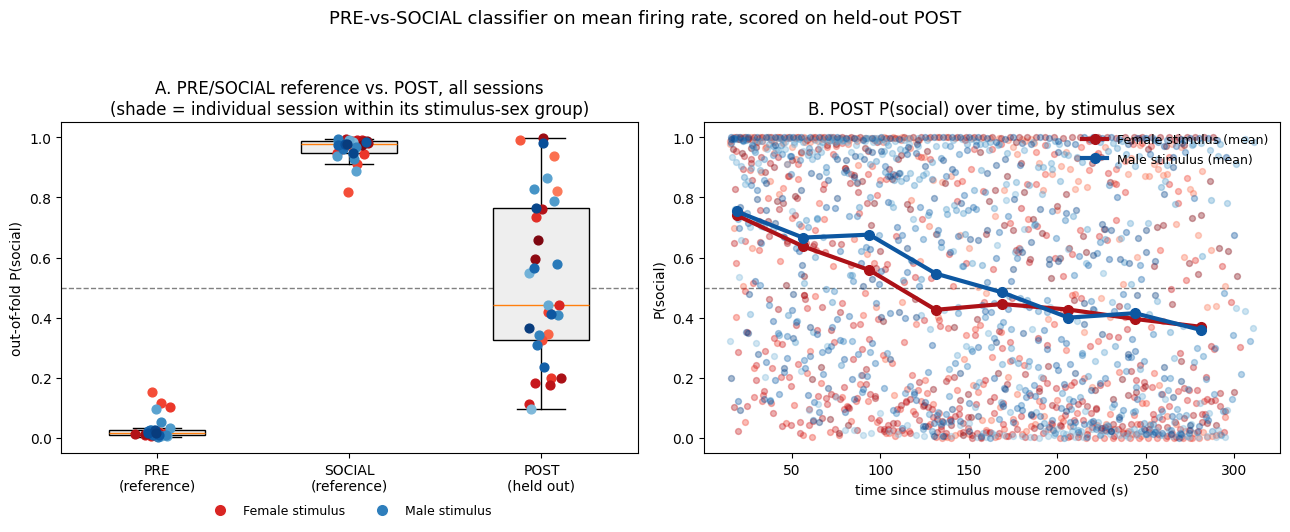

saved C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\fig2_classifier_mean_rate_by_stim.png (33 sessions)


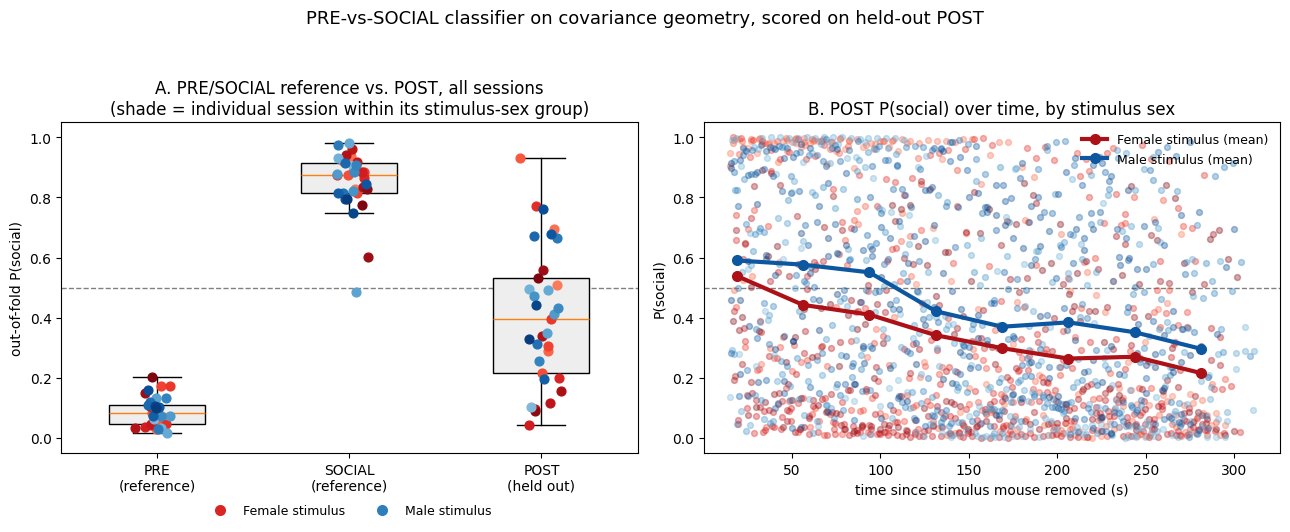

saved C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\fig4_classifier_covariance_by_stim.png (33 sessions)


In [6]:
RUNS_STIM = [
    (RESULTS_DIR / '20260915T192205_176364b7.json', 'fig2_classifier_mean_rate_by_stim',
     'mean firing rate'),
    (RESULTS_DIR / '20260915T203718_9ce7c4f8.json', 'fig4_classifier_covariance_by_stim',
     'covariance geometry'),
]

FEMALE_CMAP_S = plt.get_cmap('Reds')
MALE_CMAP_S = plt.get_cmap('Blues')


def shade_stim(stim, idx, n):
    cmap = FEMALE_CMAP_S if stim == 'Female' else MALE_CMAP_S
    return cmap(0.45 + 0.5 * (idx / max(n - 1, 1)))


def make_stim_figure(sessions, out_path, feature_label):
    by_stim = {'Female': [], 'Male': []}
    for s in sessions:
        by_stim.setdefault(s['stim'], []).append(s)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

    ax = axes[0]
    pre_vals = [s['checkpoint']['pre_ref_mean'] for s in sessions]
    soc_vals = [s['checkpoint']['social_ref_mean'] for s in sessions]
    post_vals = [s['checkpoint']['mean_p_social'] for s in sessions]
    groups_bp = [pre_vals, soc_vals, post_vals]
    bp = ax.boxplot(groups_bp, positions=[0, 1, 2], widths=0.5, patch_artist=True, showfliers=False)
    for patch in bp['boxes']:
        patch.set_facecolor('#eeeeee')
    rng_s = np.random.default_rng(0)
    for i_bp, key in enumerate(['pre_ref_mean', 'social_ref_mean', 'mean_p_social']):
        for stim, group_sessions in by_stim.items():
            n = len(group_sessions)
            for j, s in enumerate(group_sessions):
                jitter = rng_s.normal(0, 0.05)
                ax.scatter(i_bp + jitter, s['checkpoint'][key],
                           color=shade_stim(stim, j, n), s=40, zorder=3)
    ax.axhline(0.5, color='grey', ls='--', lw=1, zorder=0)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['PRE\n(reference)', 'SOCIAL\n(reference)', 'POST\n(held out)'])
    ax.set_ylabel('out-of-fold P(social)')
    ax.set_ylim(-0.05, 1.05)
    ax.set_title('A. PRE/SOCIAL reference vs. POST, all sessions\n'
                 '(shade = individual session within its stimulus-sex group)')
    handles_s = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=FEMALE_CMAP_S(0.7),
                   markersize=9, label='Female stimulus'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=MALE_CMAP_S(0.7),
                   markersize=9, label='Male stimulus')
    ]
    ax.legend(handles=handles_s, fontsize=9, loc='upper center',
              bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)

    ax = axes[1]
    for stim, group_sessions in by_stim.items():
        n = len(group_sessions)
        since_all_s, p_all_s = [], []
        for j, s in enumerate(group_sessions):
            pts = s['checkpoint'].get('points', [])
            if not pts:
                continue
            since = [p['t_since'] for p in pts]
            p_soc = [p['p_social'] for p in pts]
            ax.scatter(since, p_soc, color=shade_stim(stim, j, n), alpha=0.35, s=18, zorder=2)
            since_all_s.extend(since)
            p_all_s.extend(p_soc)
        since_all_s, p_all_s = np.array(since_all_s), np.array(p_all_s)
        if len(since_all_s) > 5:
            bins_s = np.linspace(0, 300, 9)
            bin_idx_s = np.digitize(since_all_s, bins_s) - 1
            bc_s, bm_s = [], []
            for b in range(len(bins_s) - 1):
                vals = p_all_s[bin_idx_s == b]
                if len(vals) > 0:
                    bc_s.append((bins_s[b] + bins_s[b + 1]) / 2)
                    bm_s.append(vals.mean())
            line_color_s = FEMALE_CMAP_S(0.85) if stim == 'Female' else MALE_CMAP_S(0.85)
            ax.plot(bc_s, bm_s, color=line_color_s, lw=3, marker='o', ms=7, zorder=5,
                    label=f'{stim} stimulus (mean)')
    ax.axhline(0.5, color='grey', ls='--', lw=1, zorder=0)
    ax.set_xlabel('time since stimulus mouse removed (s)')
    ax.set_ylabel('P(social)')
    ax.set_ylim(-0.05, 1.05)
    ax.set_title('B. POST P(social) over time, by stimulus sex')
    ax.legend(fontsize=9, loc='upper right', frameon=False)

    fig.suptitle(f'PRE-vs-SOCIAL classifier on {feature_label}, scored on held-out POST', fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    fig.savefig(out_path, dpi=200, bbox_inches='tight')
    plt.show()
    plt.close(fig)


for run_file_s, out_prefix_s, feature_label_s in RUNS_STIM:
    d_s = json.load(open(run_file_s))
    sessions_s = [s for s in d_s['per_session'] if s['checkpoint'].get('ps_points')]
    out_path_s = FIG_DIR / f'{out_prefix_s}.png'
    make_stim_figure(sessions_s, out_path_s, feature_label_s)
    print('saved', out_path_s, f'({len(sessions_s)} sessions)')


## 2.4 / 4.3 Per-mouse classifier breakdown

One figure per mouse for both feature representations. Sessions within each mouse colored by stimulus sex. Panel A: PRE-ref / SOCIAL-ref / POST-mean per session. Panel B: POST window-level P(social) over time.

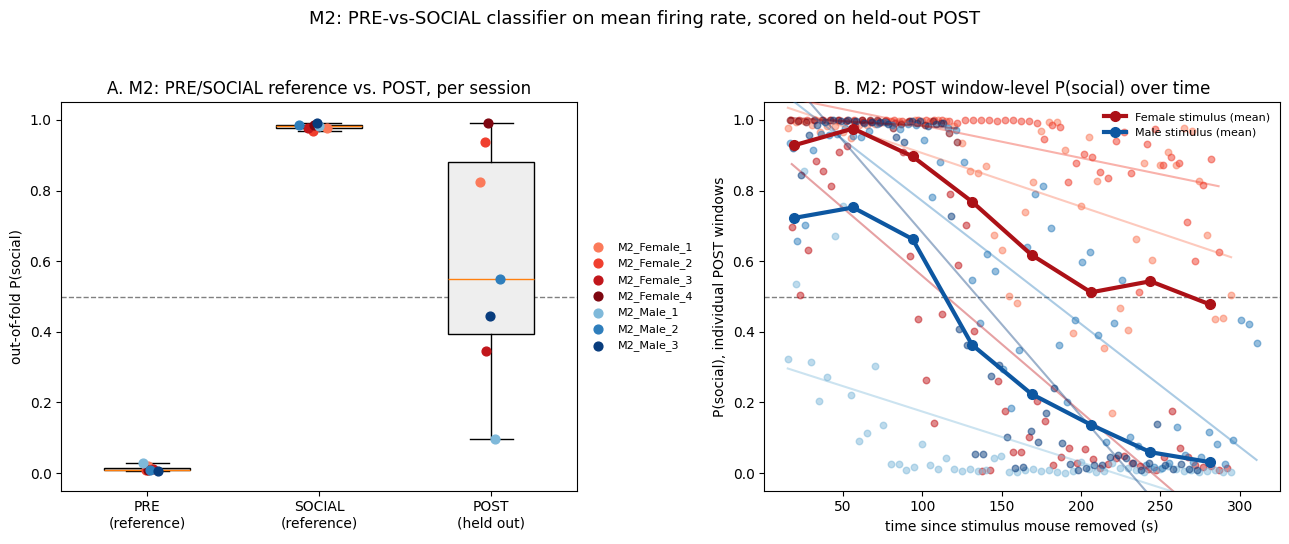

saved C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\fig2_classifier_mean_rate_M2.png (7 sessions)


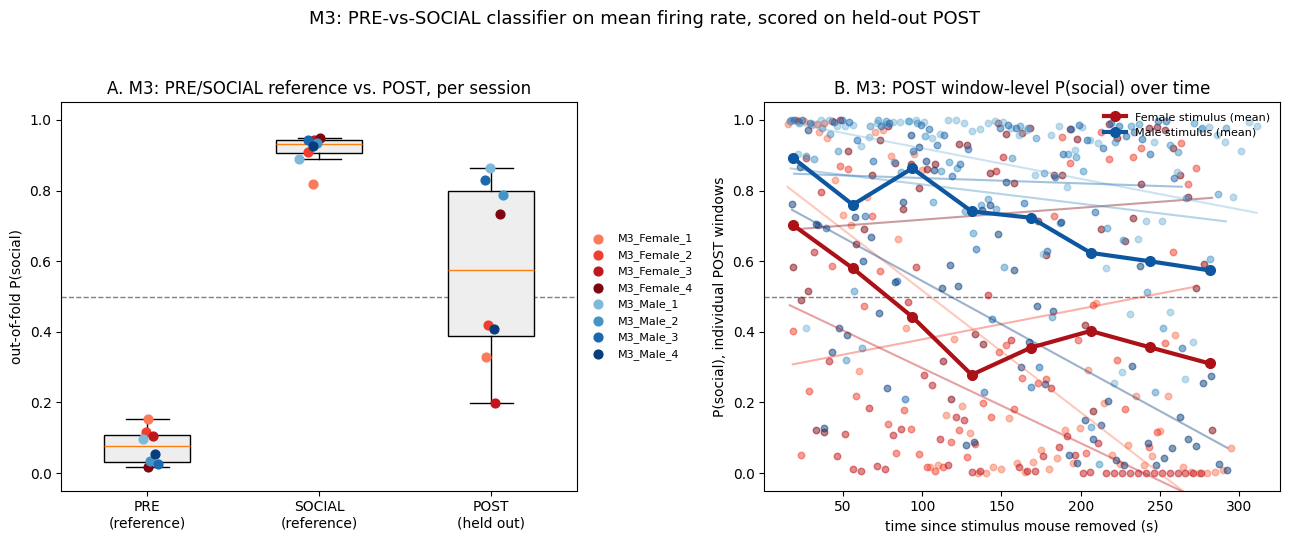

saved C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\fig2_classifier_mean_rate_M3.png (8 sessions)


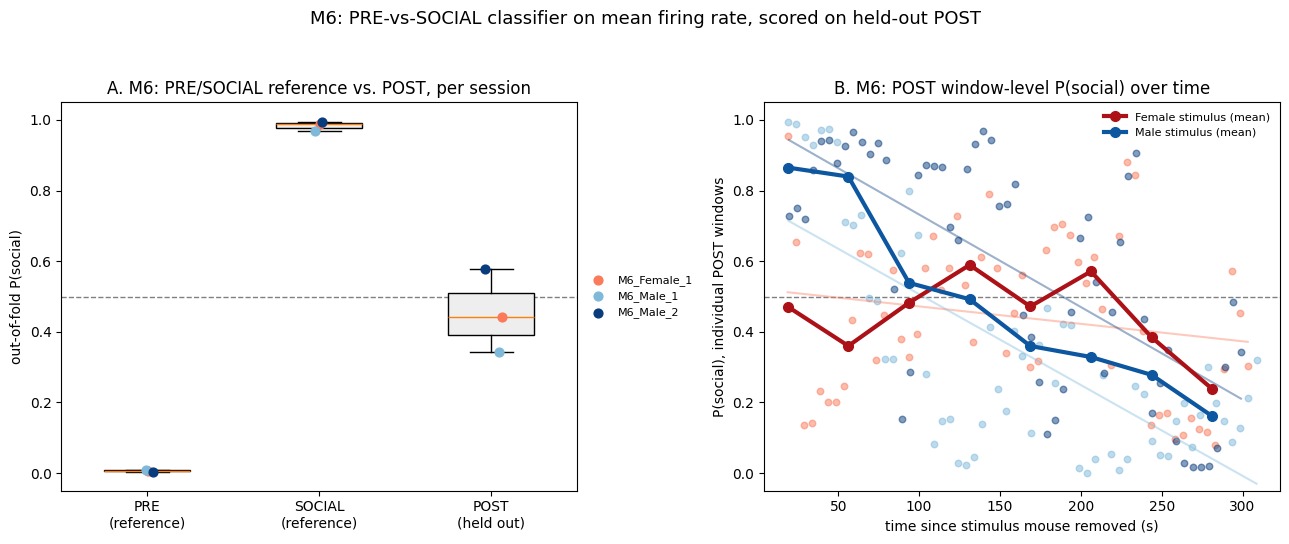

saved C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\fig2_classifier_mean_rate_M6.png (3 sessions)


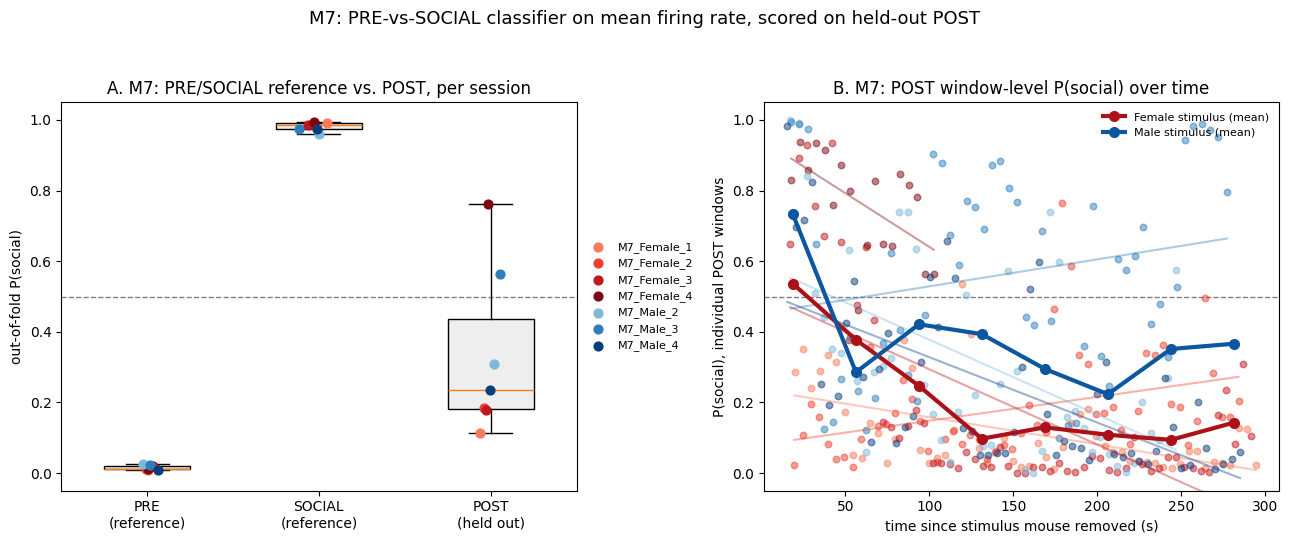

saved C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\fig2_classifier_mean_rate_M7.png (7 sessions)


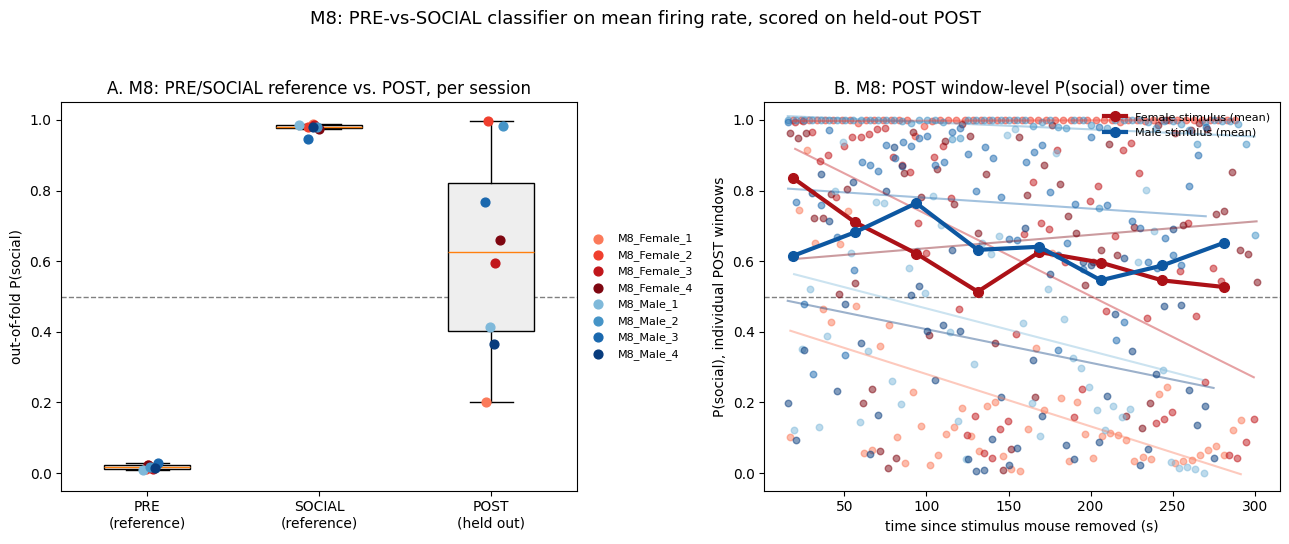

saved C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\fig2_classifier_mean_rate_M8.png (8 sessions)


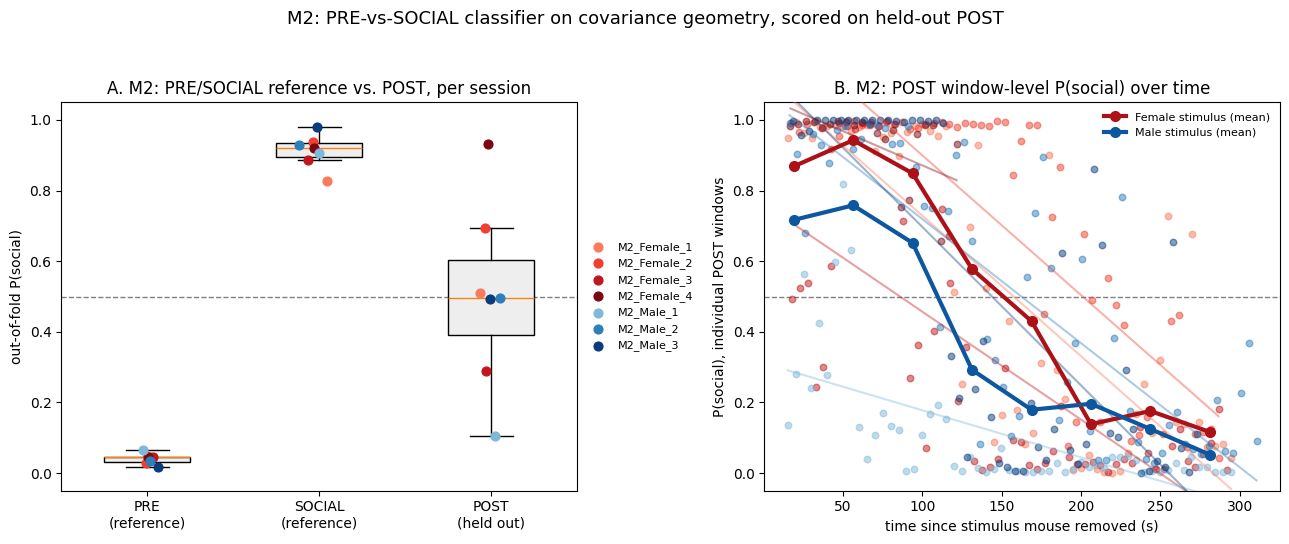

saved C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\fig4_classifier_covariance_M2.png (7 sessions)


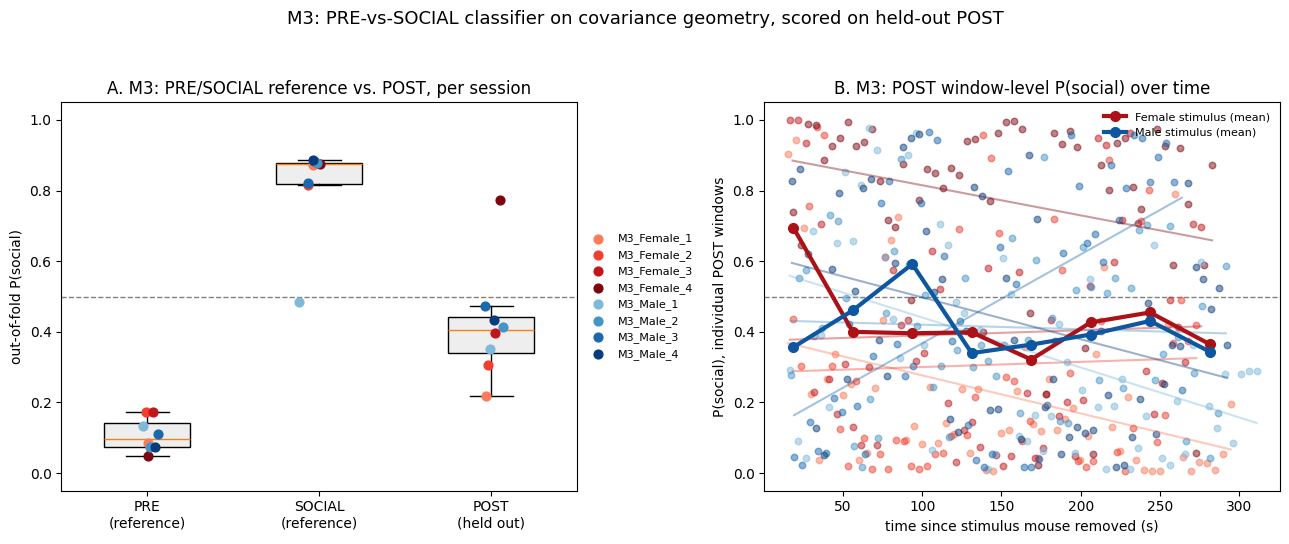

saved C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\fig4_classifier_covariance_M3.png (8 sessions)


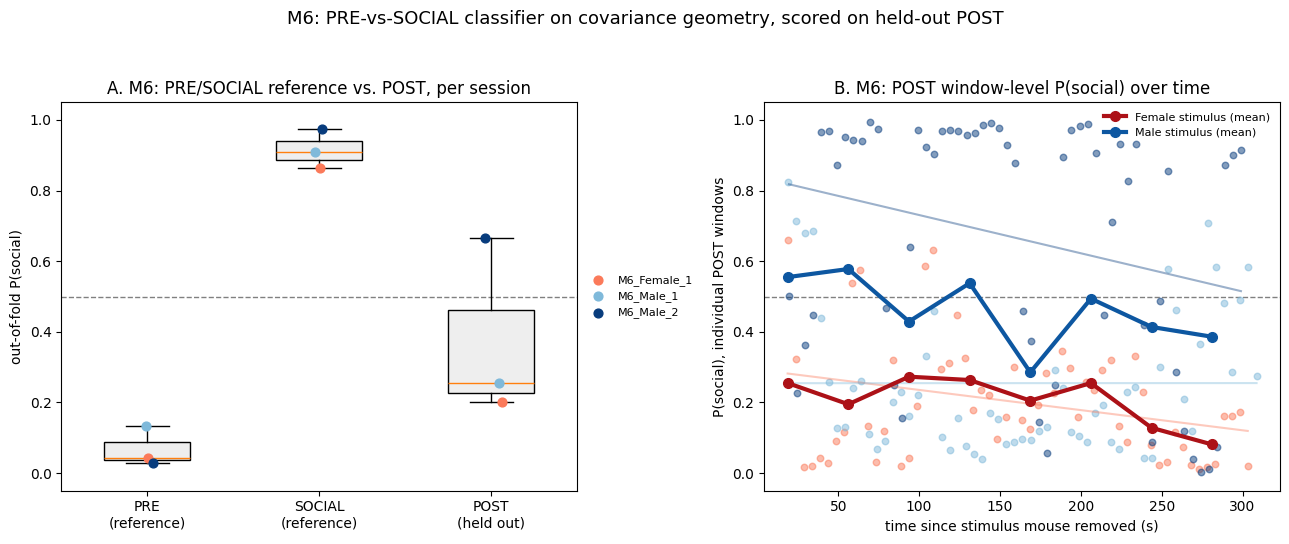

saved C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\fig4_classifier_covariance_M6.png (3 sessions)


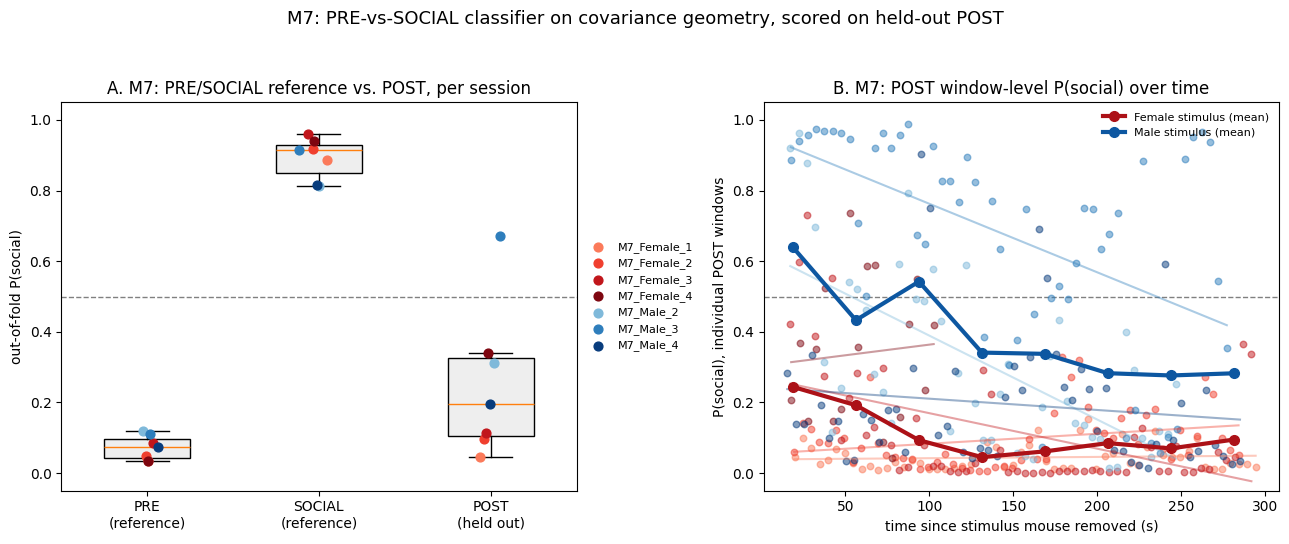

saved C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\fig4_classifier_covariance_M7.png (7 sessions)


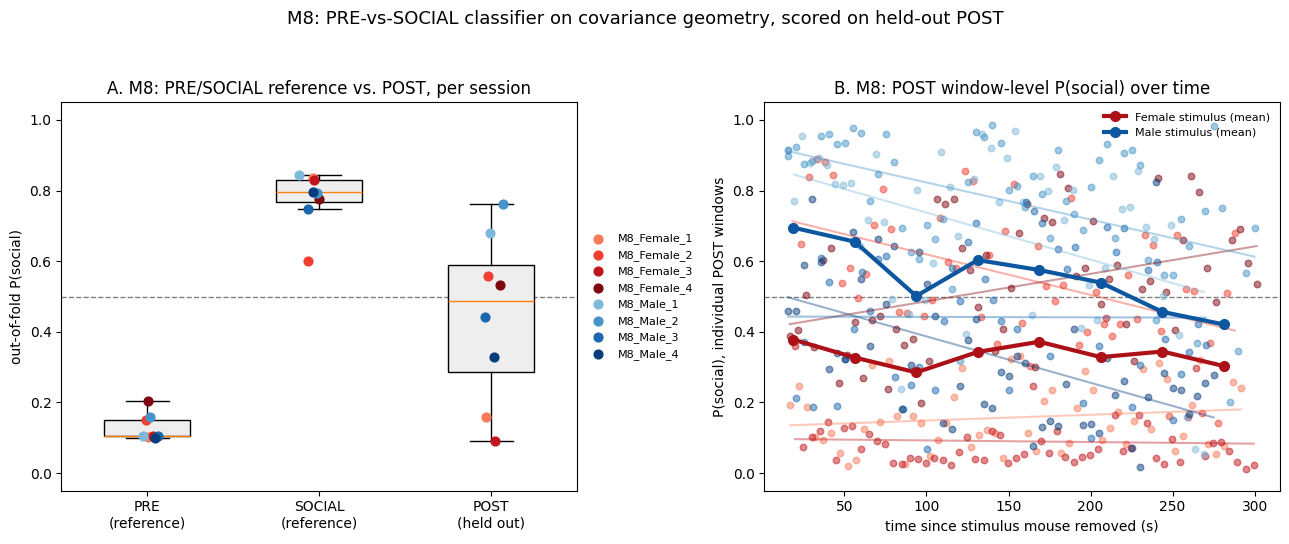

saved C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\fig4_classifier_covariance_M8.png (8 sessions)


In [7]:
RUNS_PM = [
    (RESULTS_DIR / '20260915T192205_176364b7.json', 'fig2_classifier_mean_rate',
     'mean firing rate'),
    (RESULTS_DIR / '20260915T203718_9ce7c4f8.json', 'fig4_classifier_covariance',
     'covariance geometry'),
]

FEMALE_CMAP_PM = plt.get_cmap('Reds')
MALE_CMAP_PM = plt.get_cmap('Blues')


def shade_pm(stim, idx, n):
    cmap = FEMALE_CMAP_PM if stim == 'Female' else MALE_CMAP_PM
    return cmap(0.45 + 0.5 * (idx / max(n - 1, 1)))


def make_mouse_figure(mouse, sessions, out_path, feature_label):
    by_stim_pm = {}
    for s in sessions:
        by_stim_pm.setdefault(s['stim'], []).append(s)
    colors_pm = {}
    for stim, group in by_stim_pm.items():
        for j, s in enumerate(group):
            colors_pm[s['session']] = shade_pm(stim, j, len(group))

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

    ax = axes[0]
    pre_vals_pm = [s['checkpoint']['pre_ref_mean'] for s in sessions]
    soc_vals_pm = [s['checkpoint']['social_ref_mean'] for s in sessions]
    post_vals_pm = [s['checkpoint']['mean_p_social'] for s in sessions]
    groups_pm = [pre_vals_pm, soc_vals_pm, post_vals_pm]
    bp_pm = ax.boxplot(groups_pm, positions=[0, 1, 2], widths=0.5, patch_artist=True, showfliers=False)
    for patch in bp_pm['boxes']:
        patch.set_facecolor('#eeeeee')
    rng_pm = np.random.default_rng(0)
    for i_pm, g in enumerate(groups_pm):
        for s, v in zip(sessions, g):
            jitter = rng_pm.normal(0, 0.05)
            ax.scatter(i_pm + jitter, v, color=colors_pm[s['session']], s=40, zorder=3,
                       label=s['session'] if i_pm == 0 else None)
    ax.axhline(0.5, color='grey', ls='--', lw=1, zorder=0)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['PRE\n(reference)', 'SOCIAL\n(reference)', 'POST\n(held out)'])
    ax.set_ylabel('out-of-fold P(social)')
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(f'A. {mouse}: PRE/SOCIAL reference vs. POST, per session')
    ax.legend(fontsize=8, loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=False)

    ax = axes[1]
    for stim, group in by_stim_pm.items():
        since_all_pm, p_all_pm = [], []
        for j, s in enumerate(group):
            c = s['checkpoint']
            pts = c.get('points', [])
            if not pts:
                continue
            since_pm = [p['t_since'] for p in pts]
            p_soc_pm = [p['p_social'] for p in pts]
            ax.scatter(since_pm, p_soc_pm, color=colors_pm[s['session']], alpha=0.5, s=22)
            if len(since_pm) > 1:
                slope_pm, intercept_pm = np.polyfit(since_pm, p_soc_pm, 1)
                x_line_pm = np.array([min(since_pm), max(since_pm)])
                ax.plot(x_line_pm, slope_pm * x_line_pm + intercept_pm,
                        color=colors_pm[s['session']], alpha=0.4, lw=1.5, zorder=3)
            since_all_pm.extend(since_pm)
            p_all_pm.extend(p_soc_pm)
        since_all_pm, p_all_pm = np.array(since_all_pm), np.array(p_all_pm)
        if len(since_all_pm) > 3:
            bins_pm = np.linspace(0, 300, 9)
            bin_idx_pm = np.digitize(since_all_pm, bins_pm) - 1
            bc_pm, bm_pm = [], []
            for b in range(len(bins_pm) - 1):
                vals = p_all_pm[bin_idx_pm == b]
                if len(vals) > 0:
                    bc_pm.append((bins_pm[b] + bins_pm[b + 1]) / 2)
                    bm_pm.append(vals.mean())
            line_color_pm = FEMALE_CMAP_PM(0.85) if stim == 'Female' else MALE_CMAP_PM(0.85)
            ax.plot(bc_pm, bm_pm, color=line_color_pm, lw=3, marker='o', ms=7, zorder=5,
                    label=f'{stim} stimulus (mean)')
    ax.axhline(0.5, color='grey', ls='--', lw=1, zorder=0)
    ax.set_xlabel('time since stimulus mouse removed (s)')
    ax.set_ylabel('P(social), individual POST windows')
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(f'B. {mouse}: POST window-level P(social) over time')
    ax.legend(fontsize=8, loc='upper right', frameon=False)

    fig.suptitle(f'{mouse}: PRE-vs-SOCIAL classifier on {feature_label}, scored on held-out POST',
                 fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    fig.savefig(out_path, dpi=200, bbox_inches='tight')
    plt.show()
    plt.close(fig)


for run_file_pm, out_prefix_pm, feature_label_pm in RUNS_PM:
    d_pm = json.load(open(run_file_pm))
    by_mouse_pm = {}
    for s in d_pm['per_session']:
        if not s['checkpoint'].get('ps_points'):
            continue
        by_mouse_pm.setdefault(s['mouse'], []).append(s)
    for mouse_pm, sessions_pm in sorted(by_mouse_pm.items()):
        out_path_pm = FIG_DIR / f'{out_prefix_pm}_{mouse_pm}.png'
        make_mouse_figure(mouse_pm, sessions_pm, out_path_pm, feature_label_pm)
        print('saved', out_path_pm, f'({len(sessions_pm)} sessions)')


## 2.5 / 4.4 Per-session classifier figures

Individual session-level figures for all 33 sessions &times; 2 feature types (66 figures total). Panel A: that session's PRE-ref / SOCIAL-ref / POST-mean as bars. Panel B: POST P(social) over time with linear trend. Saved to `figures_submission/per_session/`.

In [8]:
import os

PER_SESSION_DIR = FIG_DIR / 'per_session'
PER_SESSION_DIR.mkdir(exist_ok=True)

RUNS_PS = [
    (RESULTS_DIR / '20260915T192205_176364b7.json', 'rate', 'mean firing rate'),
    (RESULTS_DIR / '20260915T203718_9ce7c4f8.json', 'covariance', 'covariance geometry'),
]

BAR_COLORS_PS = ['#4ea8de', '#ff6b6b', '#a8e6cf']
STIM_COLOR_PS = {'Female': plt.get_cmap('Reds')(0.7), 'Male': plt.get_cmap('Blues')(0.7)}


def make_session_figure(s, out_path, feature_label):
    c = s['checkpoint']
    color = STIM_COLOR_PS[s['stim']]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

    ax = axes[0]
    vals = [c['pre_ref_mean'], c['social_ref_mean'], c['mean_p_social']]
    ax.bar([0, 1, 2], vals, color=BAR_COLORS_PS, width=0.6)
    ax.axhline(0.5, color='grey', ls='--', lw=1, zorder=0)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['PRE\n(ref)', 'SOCIAL\n(ref)', 'POST\n(held out)'])
    ax.set_ylabel('out-of-fold P(social)')
    ax.set_ylim(0, 1.05)
    ax.set_title('A. PRE/SOCIAL reference vs. POST')

    ax = axes[1]
    pts = c.get('points', [])
    if pts:
        since_ps = np.array([p['t_since'] for p in pts])
        p_soc_ps = np.array([p['p_social'] for p in pts])
        ax.scatter(since_ps, p_soc_ps, color=color, alpha=0.6, s=24)
        if len(since_ps) > 1:
            slope_ps, intercept_ps = np.polyfit(since_ps, p_soc_ps, 1)
            x_line_ps = np.array([since_ps.min(), since_ps.max()])
            ax.plot(x_line_ps, slope_ps * x_line_ps + intercept_ps, color=color, lw=2.5)
    ax.axhline(0.5, color='grey', ls='--', lw=1, zorder=0)
    ax.set_xlabel('time since stimulus mouse removed (s)')
    ax.set_ylabel('P(social)')
    ax.set_ylim(-0.05, 1.05)
    ax.set_title('B. POST window-level P(social) over time')

    fig.suptitle(f"{s['session']} ({s['stim']} stimulus): PRE-vs-SOCIAL classifier on "
                 f'{feature_label}', fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.92])
    fig.savefig(out_path, dpi=160, bbox_inches='tight')
    plt.close(fig)


for run_file_ps, feat_key_ps, feature_label_ps in RUNS_PS:
    d_ps = json.load(open(run_file_ps))
    sessions_ps = [s for s in d_ps['per_session'] if s['checkpoint'].get('ps_points')]
    for s in sessions_ps:
        out_path_ps = PER_SESSION_DIR / f"{s['session']}_{feat_key_ps}.png"
        make_session_figure(s, out_path_ps, feature_label_ps)
    print(f'{feat_key_ps}: saved {len(sessions_ps)} session figures to', PER_SESSION_DIR)


rate: saved 33 session figures to C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\per_session
covariance: saved 33 session figures to C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\per_session


## 2.6 Regularization robustness check (Fig. 2c)

For sessions with the weakest POST decay slope, we verify robustness to regularization strength (C &isin; {1.0, 0.01, 0.001}) and training-data amount (100%, 20%, 10%). A consistent POST trajectory across conditions confirms the decay is not an artifact of overfitting.

M2_Female_1


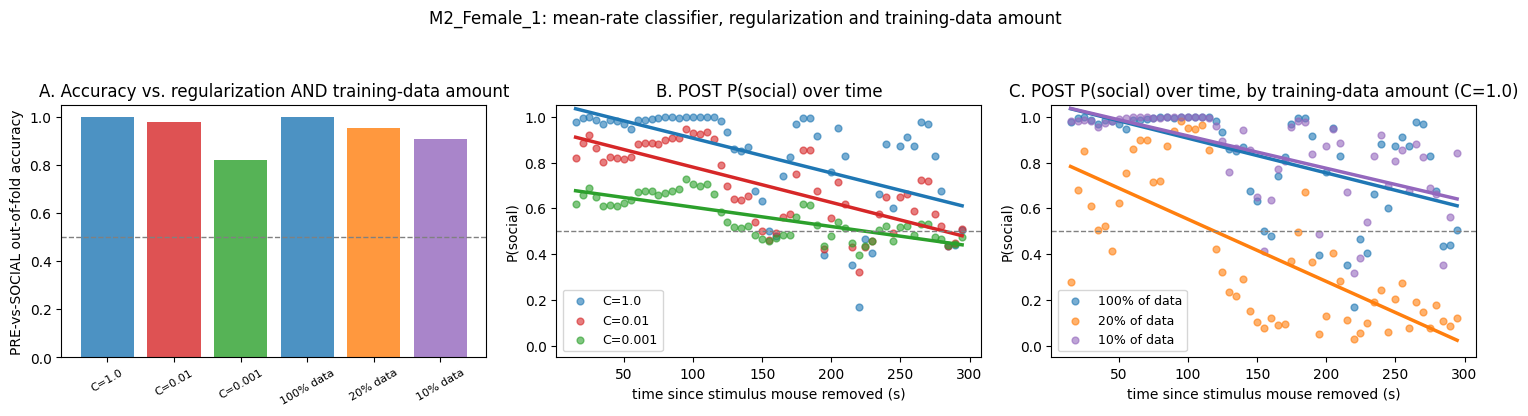

saved C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\fig_M2_Female_1_regularization_check.png
M3_Male_3


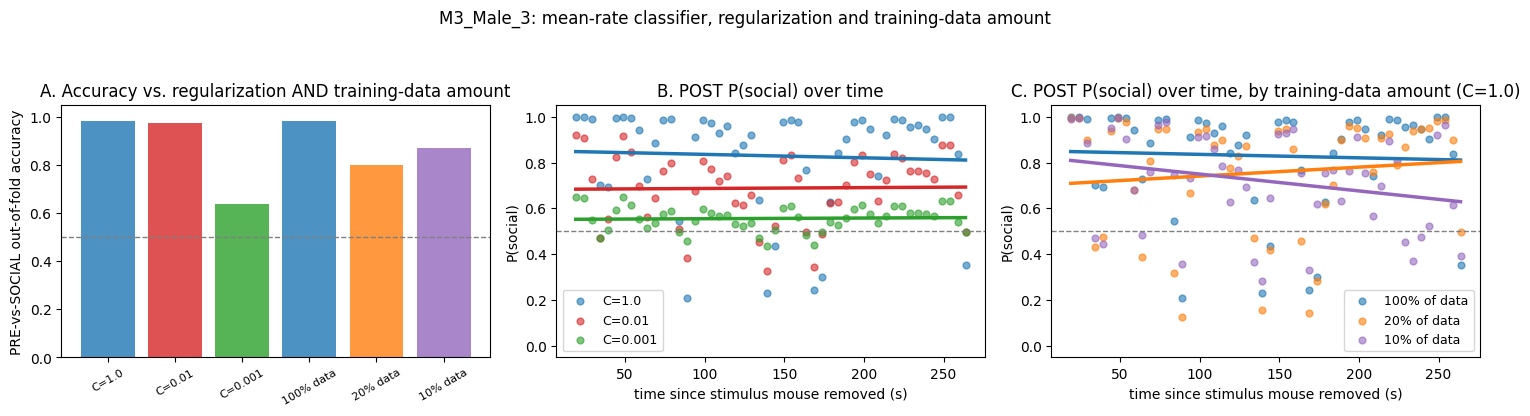

saved C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\fig_M3_Male_3_regularization_check.png
M8_Male_2


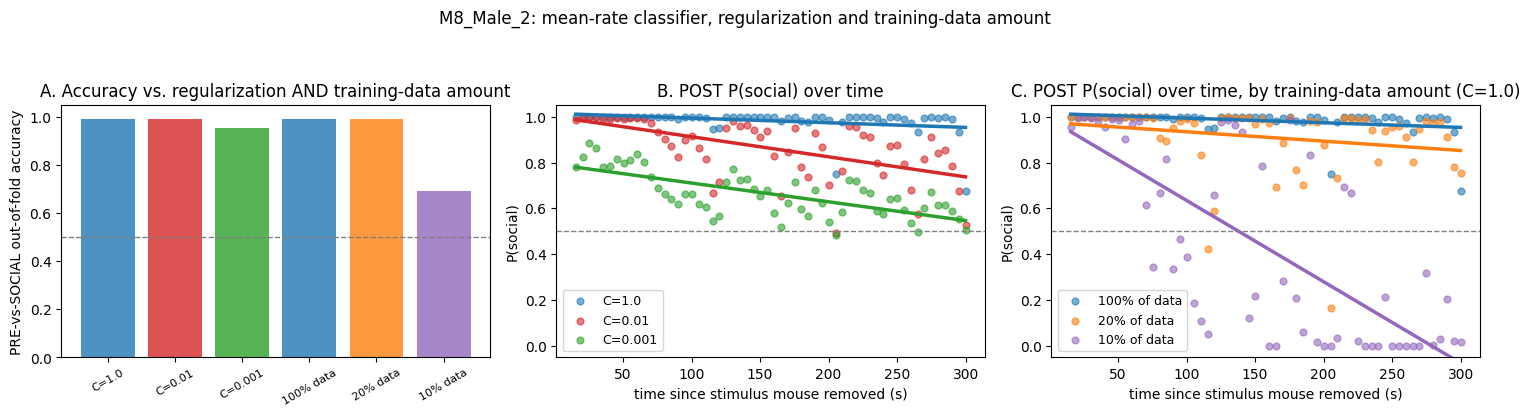

saved C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\fig_M8_Male_2_regularization_check.png
M8_Male_3


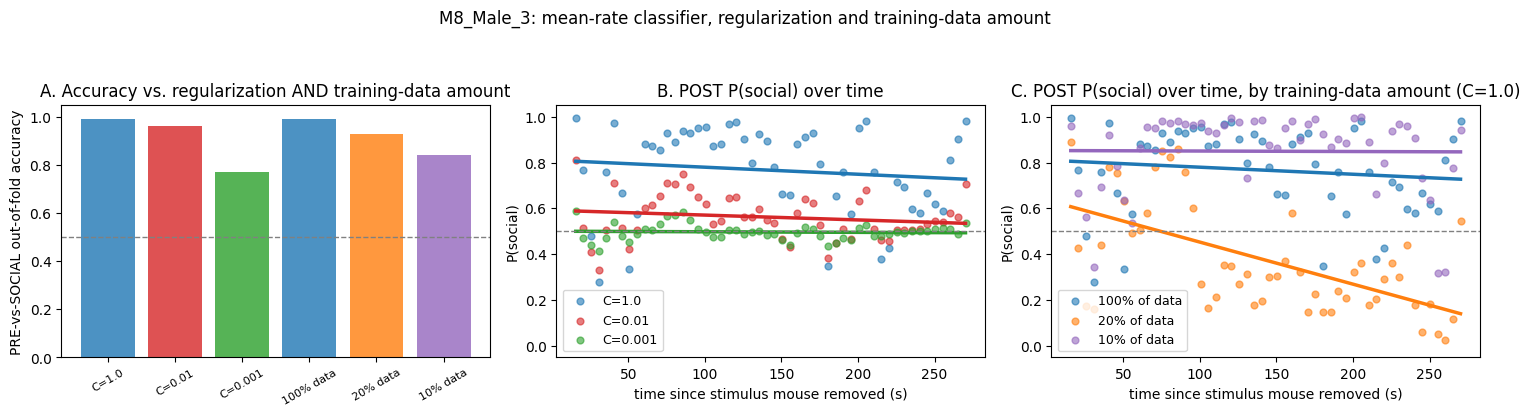

saved C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\fig_M8_Male_3_regularization_check.png
M3_Female_4


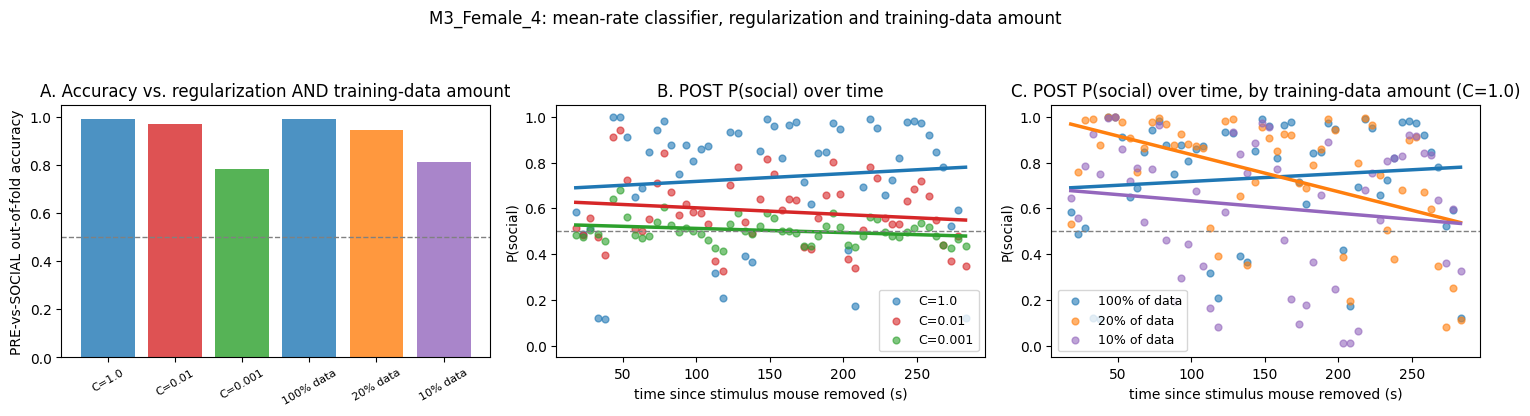

saved C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\fig_M3_Female_4_regularization_check.png
M8_Female_4


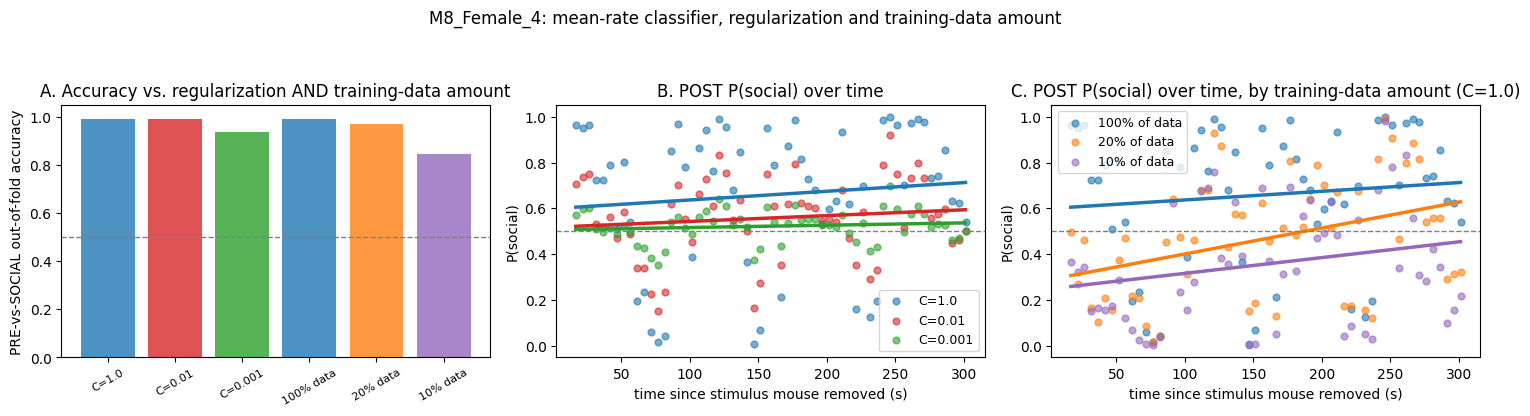

saved C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\fig_M8_Female_4_regularization_check.png
M6_Female_1


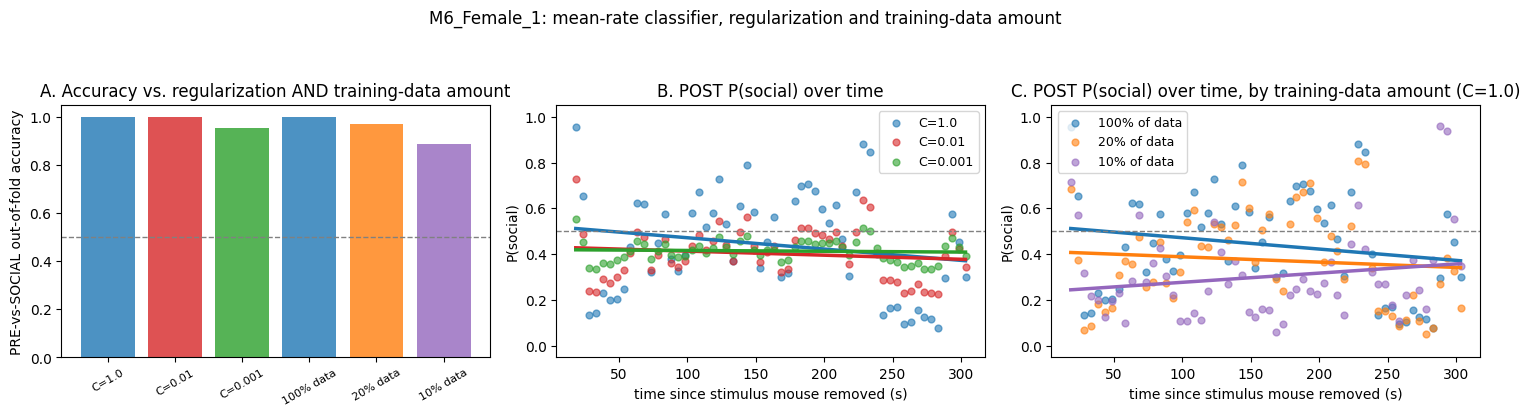

saved C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\fig_M6_Female_1_regularization_check.png


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from Main.gui import classifiers as clf_mod_rc

C_VALUES_RC = [1.0, 0.01, 0.001]
FRACTIONS_RC = [1.0, 0.2, 0.1]
SESSIONS_RC = ['M2_Female_1', 'M3_Male_3', 'M8_Male_2', 'M8_Male_3', 'M3_Female_4',
                'M8_Female_4', 'M6_Female_1']


def run_regularization_check(session_rc):
    rec_rc = dl.load_session_record(session_rc, guard_s=GUARD_S, data_dir=DATA_DIR)
    Y_rc, _ = feat_mod.get_channels(rec_rc, 'rate', feat_mod.CHANNEL_MODE_CELLS,
                                     subset_kind=feat_mod.NEURON_SUBSET_ALL)
    X_rc_all, y_raw_rc, tc_rc_all = feat_mod.make_rate_windows(
        Y_rc, rec_rc['t'], rec_rc['phase'], WIN_S, STEP_S, dl.FPS, keep_labels=(0, 1, 2))

    train_mask_rc = np.isin(y_raw_rc, [0, 1])
    held_mask_rc = y_raw_rc == 2
    X_ps_rc, y_ps_rc = X_rc_all[train_mask_rc], y_raw_rc[train_mask_rc]
    X_post_rc = X_rc_all[held_mask_rc]
    since_post_rc = tc_rc_all[held_mask_rc] - rec_rc['t_out']
    if len(y_ps_rc) < 10 or len(X_post_rc) < 5:
        print(f'skip {session_rc}: too few windows')
        return

    folds_rc = clf_mod_rc.random_block_cv(len(y_ps_rc), k=5, seed=0)

    fig_rc, axes_rc = plt.subplots(1, 3, figsize=(15, 4.2))

    for C_val, color_rc in zip(C_VALUES_RC, ['#1f77b4', '#d62728', '#2ca02c']):
        oof_rc = np.full(len(y_ps_rc), np.nan)
        for tr, te in folds_rc:
            if len(np.unique(y_ps_rc[tr])) < 2:
                continue
            clf_r = Pipeline([('scaler', StandardScaler()),
                               ('clf', LogisticRegression(C=C_val, max_iter=2000))])
            clf_r.fit(X_ps_rc[tr], y_ps_rc[tr])
            proba = clf_r.predict_proba(X_ps_rc[te])
            pos_col = list(clf_r.named_steps['clf'].classes_).index(1)
            oof_rc[te] = proba[:, pos_col]
        acc_rc = np.nanmean((oof_rc > 0.5).astype(int) == y_ps_rc)

        clf_full_r = Pipeline([('scaler', StandardScaler()),
                                ('clf', LogisticRegression(C=C_val, max_iter=2000))])
        clf_full_r.fit(X_ps_rc, y_ps_rc)
        pos_col = list(clf_full_r.named_steps['clf'].classes_).index(1)
        p_post_rc = clf_full_r.predict_proba(X_post_rc)[:, pos_col]

        axes_rc[0].bar([f'C={C_val}'], [acc_rc], color=color_rc, alpha=0.8)
        axes_rc[1].scatter(since_post_rc, p_post_rc, color=color_rc, alpha=0.6, s=24,
                           label=f'C={C_val}')
        if len(since_post_rc) > 1:
            slope_r, intercept_r = np.polyfit(since_post_rc, p_post_rc, 1)
            x_line_r = np.array([since_post_rc.min(), since_post_rc.max()])
            axes_rc[1].plot(x_line_r, slope_r * x_line_r + intercept_r, color=color_rc, lw=2.5)

    rng_rc = np.random.default_rng(0)
    for frac, color_rc in zip(FRACTIONS_RC, ['#1f77b4', '#ff7f0e', '#9467bd']):
        oof_f = np.full(len(y_ps_rc), np.nan)
        for tr, te in folds_rc:
            n_use = max(2, int(round(len(tr) * frac)))
            sub = rng_rc.choice(tr, size=n_use, replace=False)
            if len(np.unique(y_ps_rc[sub])) < 2:
                continue
            clf_f = Pipeline([('scaler', StandardScaler()),
                               ('clf', LogisticRegression(C=1.0, max_iter=2000))])
            clf_f.fit(X_ps_rc[sub], y_ps_rc[sub])
            proba = clf_f.predict_proba(X_ps_rc[te])
            pos_col = list(clf_f.named_steps['clf'].classes_).index(1)
            oof_f[te] = proba[:, pos_col]
        acc_frac = np.nanmean((oof_f > 0.5).astype(int) == y_ps_rc)

        n_use_full = max(2, int(round(len(y_ps_rc) * frac)))
        sub_full = rng_rc.choice(len(y_ps_rc), size=n_use_full, replace=False)
        clf_ff = Pipeline([('scaler', StandardScaler()),
                            ('clf', LogisticRegression(C=1.0, max_iter=2000))])
        clf_ff.fit(X_ps_rc[sub_full], y_ps_rc[sub_full])
        pos_col = list(clf_ff.named_steps['clf'].classes_).index(1)
        p_post_frac = clf_ff.predict_proba(X_post_rc)[:, pos_col]

        axes_rc[0].bar([f'{int(frac*100)}% data'], [acc_frac], color=color_rc, alpha=0.8)
        axes_rc[2].scatter(since_post_rc, p_post_frac, color=color_rc, alpha=0.6, s=24,
                           label=f'{int(frac*100)}% of data')
        if len(since_post_rc) > 1:
            slope_f, intercept_f = np.polyfit(since_post_rc, p_post_frac, 1)
            x_line_f = np.array([since_post_rc.min(), since_post_rc.max()])
            axes_rc[2].plot(x_line_f, slope_f * x_line_f + intercept_f, color=color_rc, lw=2.5)

    axes_rc[1].axhline(0.5, color='grey', ls='--', lw=1)
    axes_rc[1].set_ylim(-0.05, 1.05)
    axes_rc[1].set_xlabel('time since stimulus mouse removed (s)')
    axes_rc[1].set_ylabel('P(social)')
    axes_rc[1].set_title('B. POST P(social) over time')
    axes_rc[1].legend(fontsize=9)

    axes_rc[0].axhline(0.5, color='grey', ls='--', lw=1)
    axes_rc[0].set_ylim(0, 1.05)
    axes_rc[0].set_ylabel('PRE-vs-SOCIAL out-of-fold accuracy')
    axes_rc[0].set_title('A. Accuracy vs. regularization AND training-data amount')
    axes_rc[0].tick_params(axis='x', labelsize=8, labelrotation=30)

    axes_rc[2].axhline(0.5, color='grey', ls='--', lw=1)
    axes_rc[2].set_ylim(-0.05, 1.05)
    axes_rc[2].set_xlabel('time since stimulus mouse removed (s)')
    axes_rc[2].set_ylabel('P(social)')
    axes_rc[2].set_title('C. POST P(social) over time, by training-data amount (C=1.0)')
    axes_rc[2].legend(fontsize=9)

    fig_rc.suptitle(f'{session_rc}: mean-rate classifier, regularization and training-data amount',
                    fontsize=12)
    fig_rc.tight_layout(rect=[0, 0, 1, 0.92])
    out_rc = FIG_DIR / f'fig_{session_rc}_regularization_check.png'
    fig_rc.savefig(out_rc, dpi=180, bbox_inches='tight')
    plt.show()
    plt.close(fig_rc)
    print('saved', out_rc)


for session_rc_item in SESSIONS_RC:
    print(session_rc_item)
    run_regularization_check(session_rc_item)


---
# Step 3: Diffusion-map clustering of population covariance structure

## 3.1 Per-session diffusion maps

For each of 3 example sessions, builds sliding correlation matrices over all recorded cells and embeds them with the Ghanayim/Benisty et al. diffusion-map method. Each phase's Riemannian mean is embedded as a landmark centroid. Produces the diffusion-map figures shown in the report.

M7_Female_1: 168 windows, 166 channels


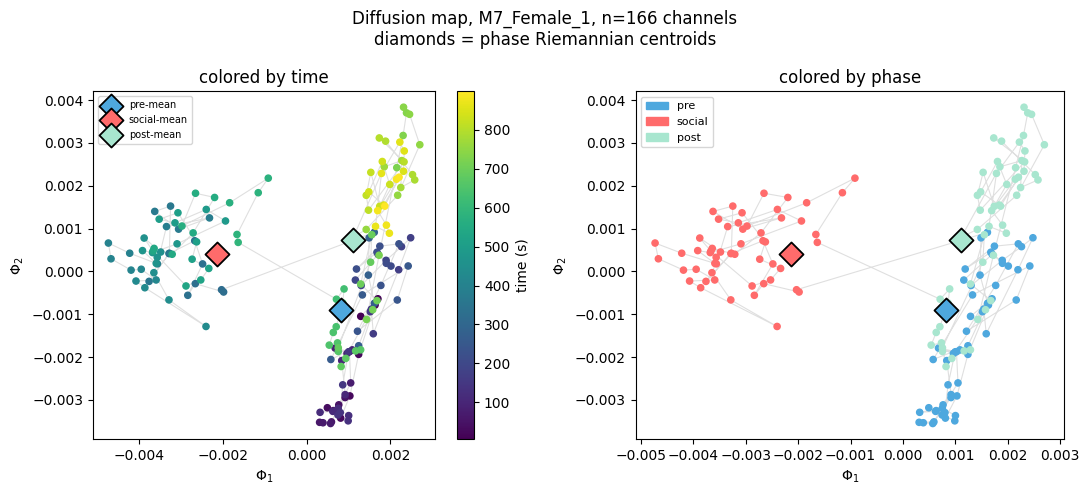

M6_Male_1: 165 windows, 250 channels


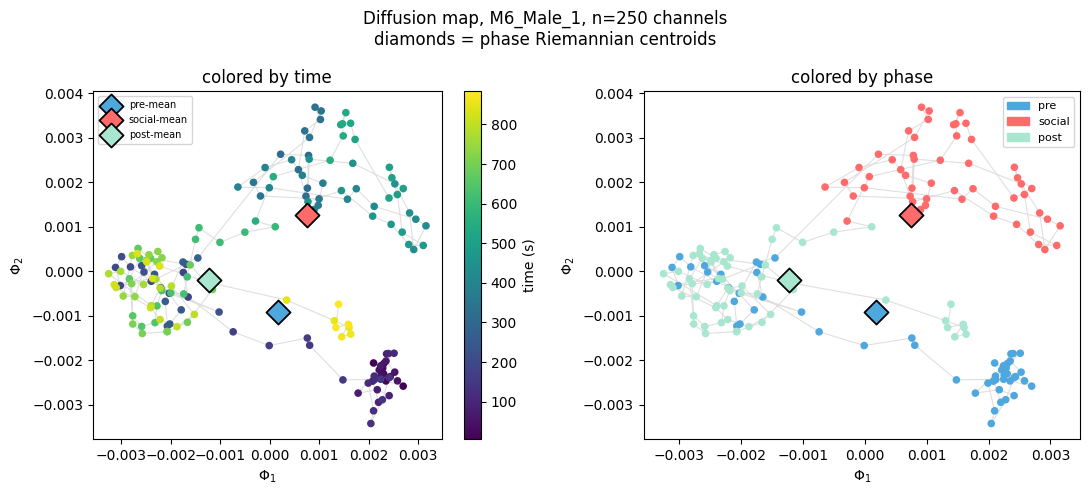

M2_Male_2: 169 windows, 146 channels


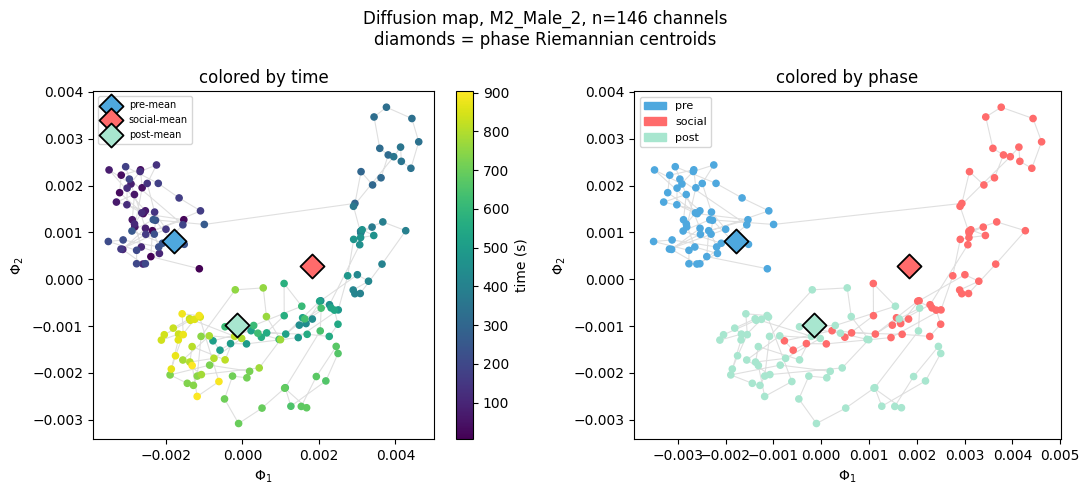

In [10]:
DIFFMAP_SESSIONS = ["M7_Female_1", "M6_Male_1", "M2_Male_2"]

for session in DIFFMAP_SESSIONS:
    rec = dl.load_session_record(session, guard_s=GUARD_S, data_dir=DATA_DIR)
    Y, _ = feat_mod.get_channels(rec, "covariance", feat_mod.CHANNEL_MODE_CELLS,
                                  subset_kind=feat_mod.NEURON_SUBSET_ALL)
    mats, tc, lab = feat_mod.build_covariance_windows(Y, rec["t"], rec["phase"], win_s=WIN_S, step_s=STEP_S,
                                                        lam_scale=LAM_SCALE, fps=dl.FPS, all_cells=True)
    print(f"{session}: {len(mats)} windows, {Y.shape[0]} channels")
    fig = covariance_viz.diffusion_map_figure(rec["session"], mats, tc, lab)
    fig.savefig(FIG_DIR / f"fig_diffmap_{session}.png", dpi=200, bbox_inches="tight")
    plt.show()

## 3.2 PCA by phase - linear-method comparison

Simple 2D PCA on the same z-scored mean-rate window features used by the classifier, for all 33 sessions, colored by phase (PRE=blue, SOCIAL=red, POST=green). Diamond markers show phase centroids. This is the linear-method counterpart to the covariance-geometry diffusion map from Step 3.

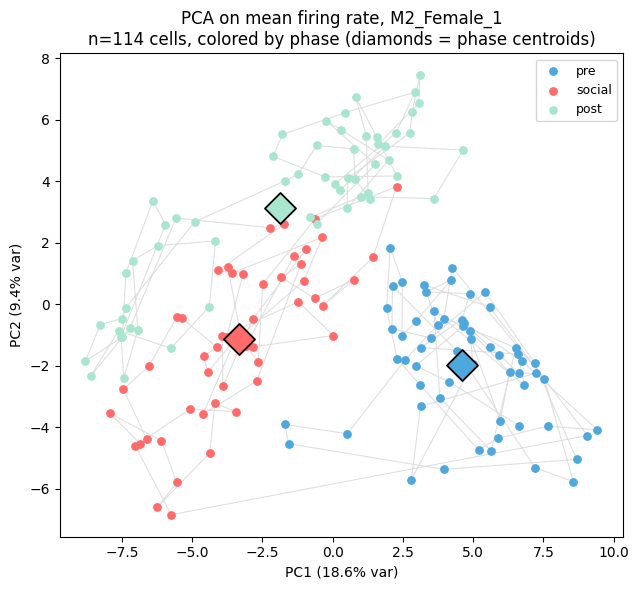

saved C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\fig_pca_M2_Female_1.png PC1+PC2 explain 28.1% of variance


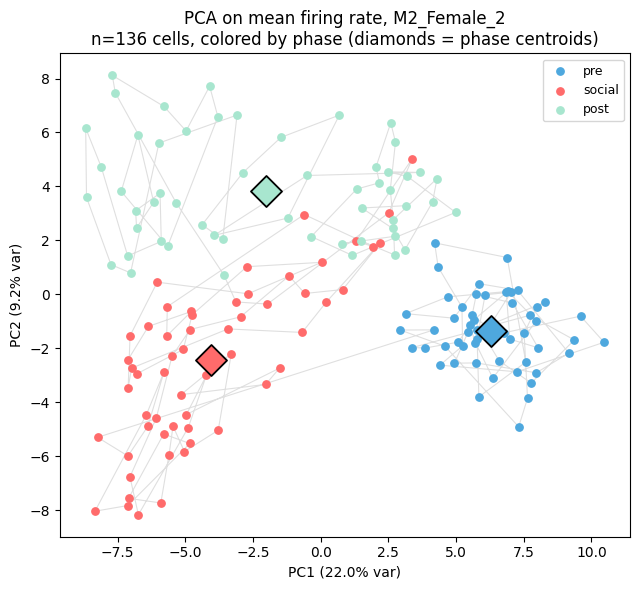

saved C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\fig_pca_M2_Female_2.png PC1+PC2 explain 31.2% of variance


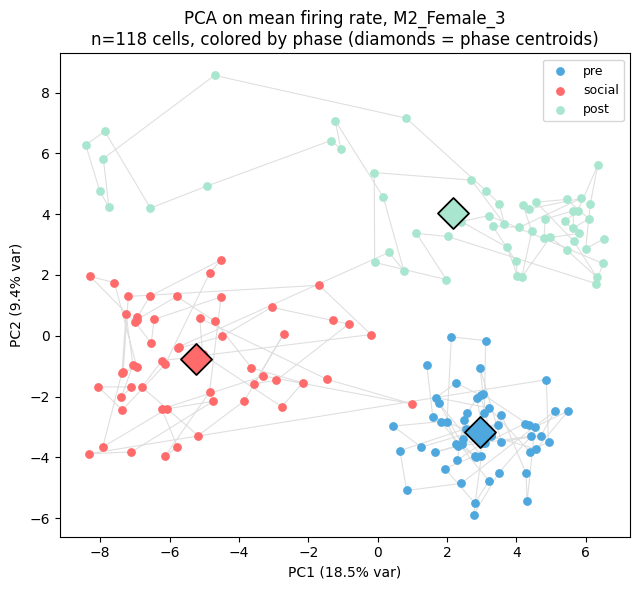

saved C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\fig_pca_M2_Female_3.png PC1+PC2 explain 27.9% of variance


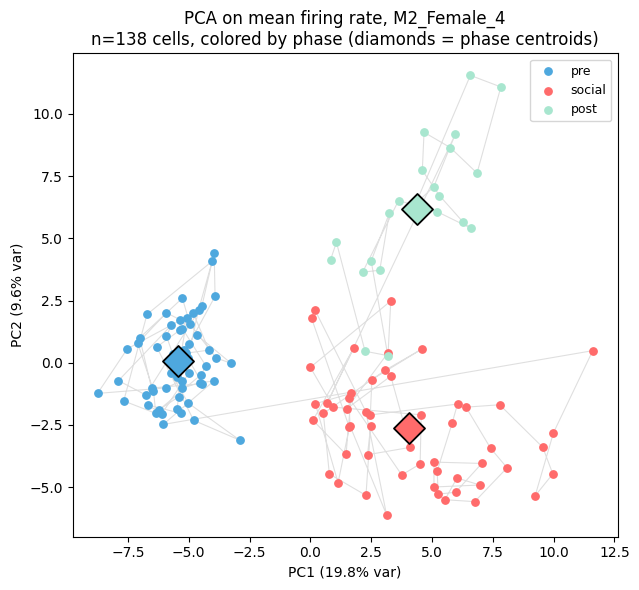

saved C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\fig_pca_M2_Female_4.png PC1+PC2 explain 29.4% of variance


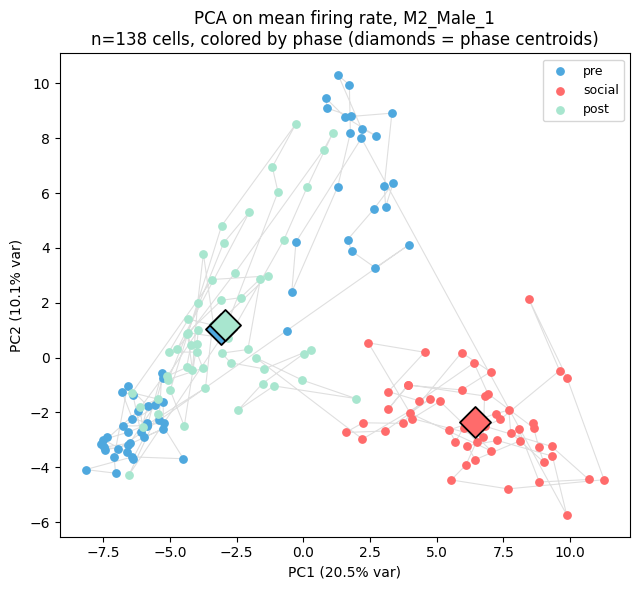

saved C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\fig_pca_M2_Male_1.png PC1+PC2 explain 30.6% of variance


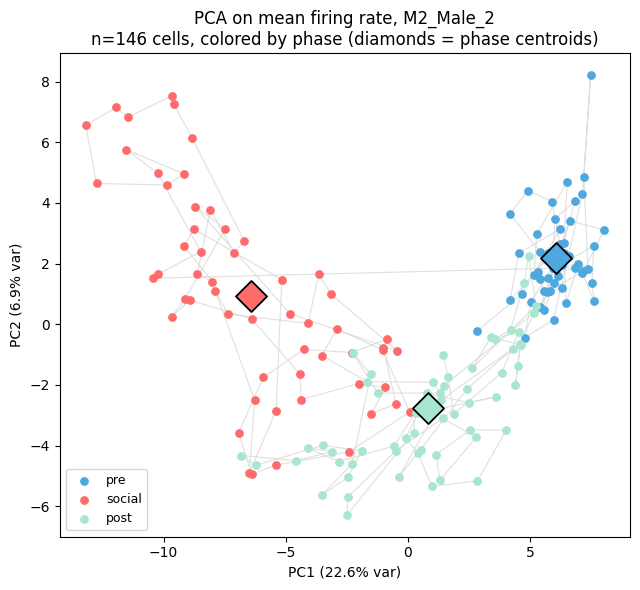

saved C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\fig_pca_M2_Male_2.png PC1+PC2 explain 29.5% of variance


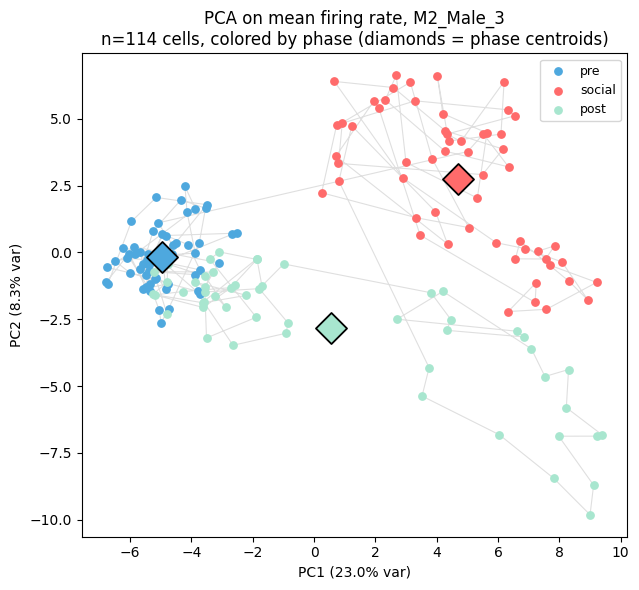

saved C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\fig_pca_M2_Male_3.png PC1+PC2 explain 31.2% of variance


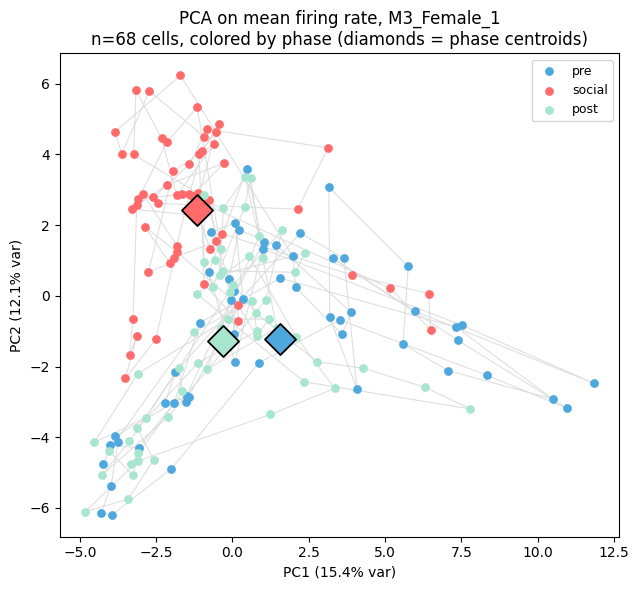

saved C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\fig_pca_M3_Female_1.png PC1+PC2 explain 27.5% of variance


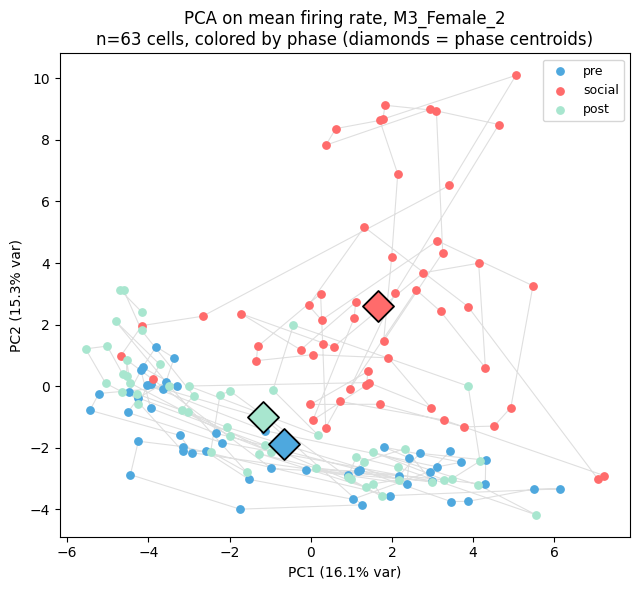

saved C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\fig_pca_M3_Female_2.png PC1+PC2 explain 31.4% of variance


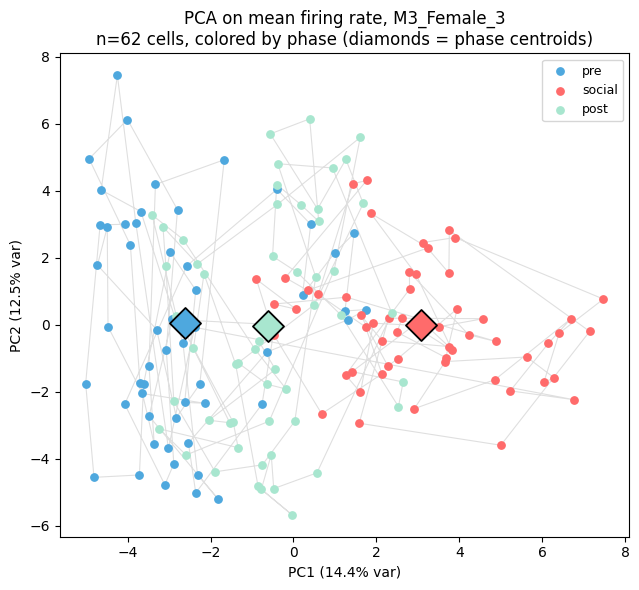

saved C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\fig_pca_M3_Female_3.png PC1+PC2 explain 26.8% of variance


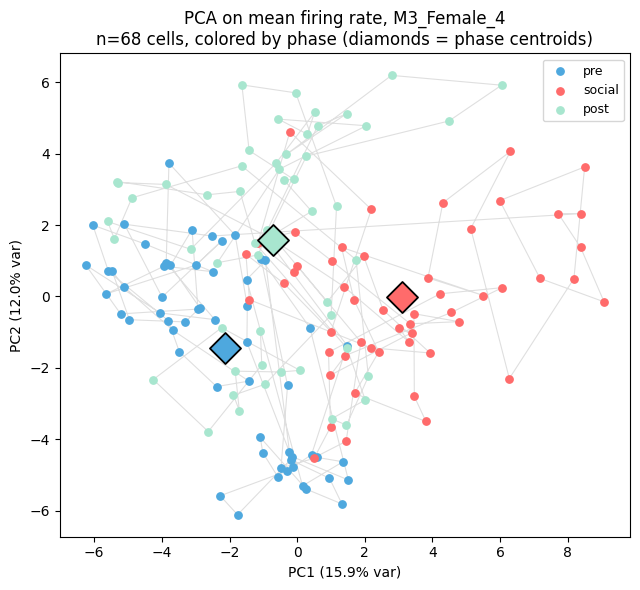

saved C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\fig_pca_M3_Female_4.png PC1+PC2 explain 27.9% of variance


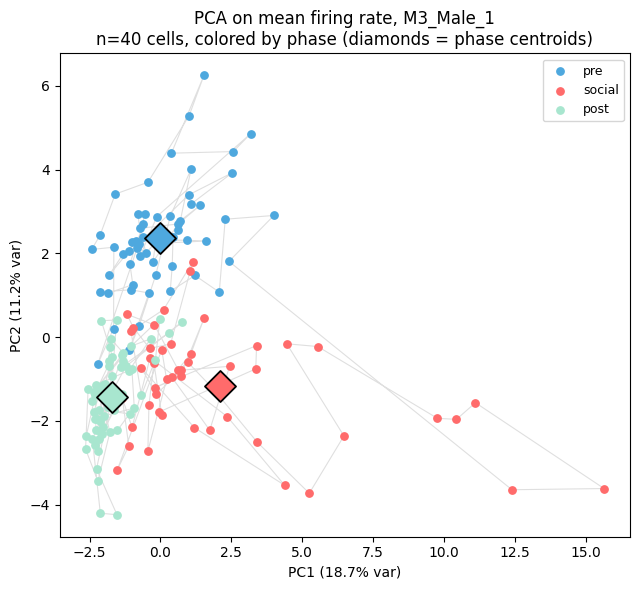

saved C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\fig_pca_M3_Male_1.png PC1+PC2 explain 29.9% of variance


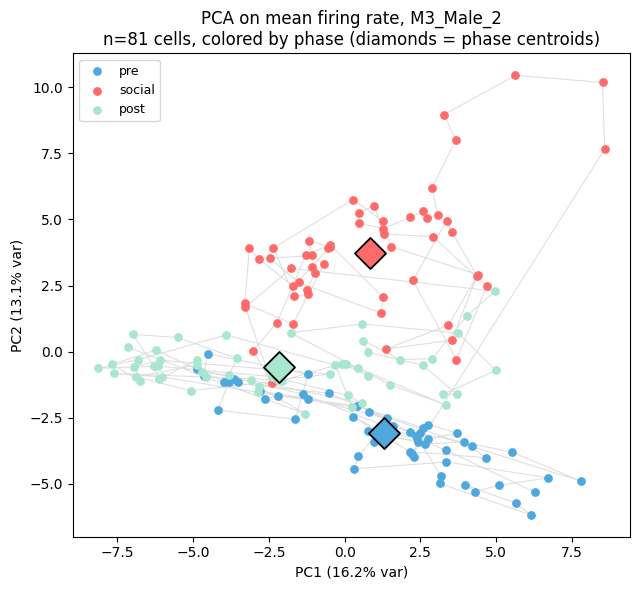

saved C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\fig_pca_M3_Male_2.png PC1+PC2 explain 29.4% of variance


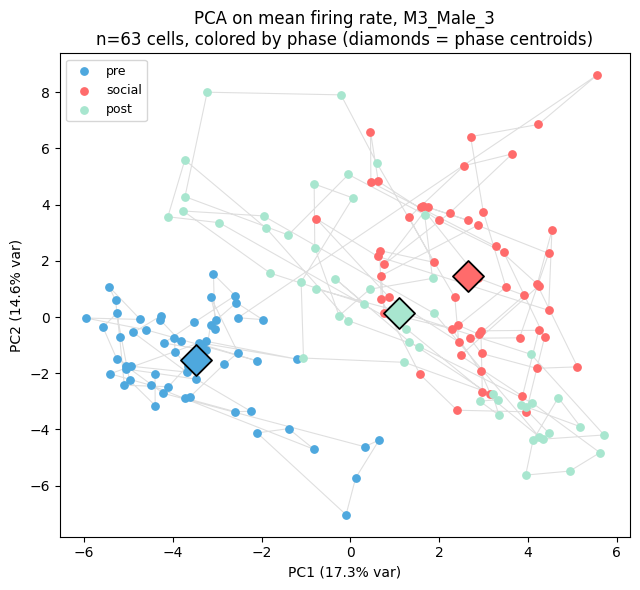

saved C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\fig_pca_M3_Male_3.png PC1+PC2 explain 31.9% of variance


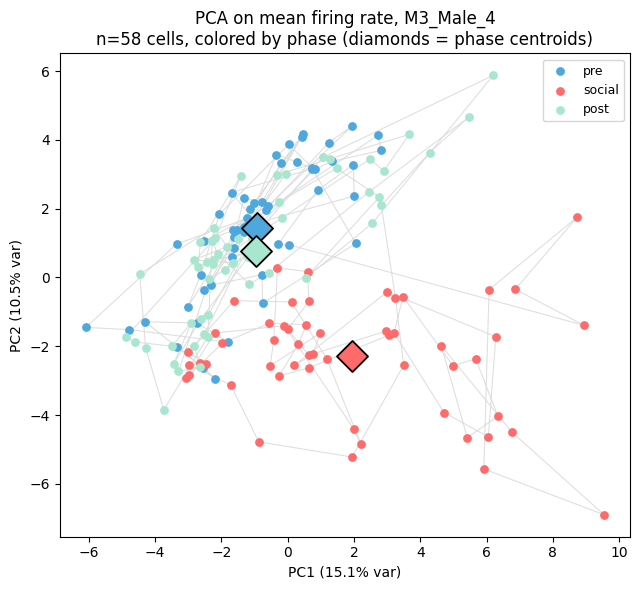

saved C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\fig_pca_M3_Male_4.png PC1+PC2 explain 25.6% of variance


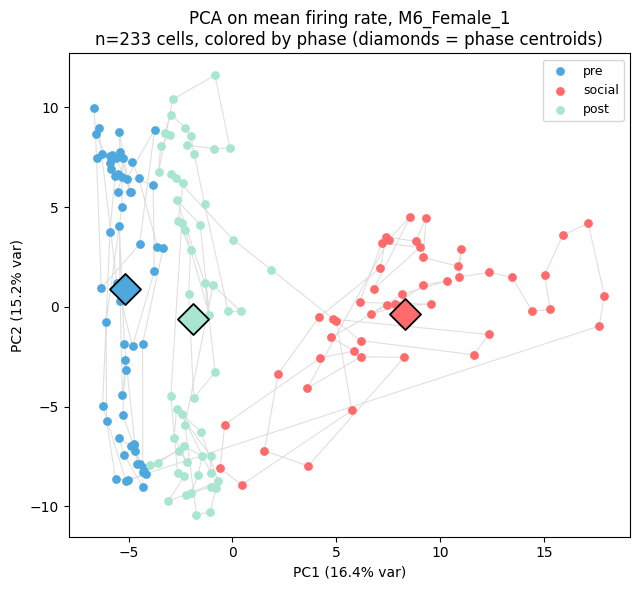

saved C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\fig_pca_M6_Female_1.png PC1+PC2 explain 31.6% of variance


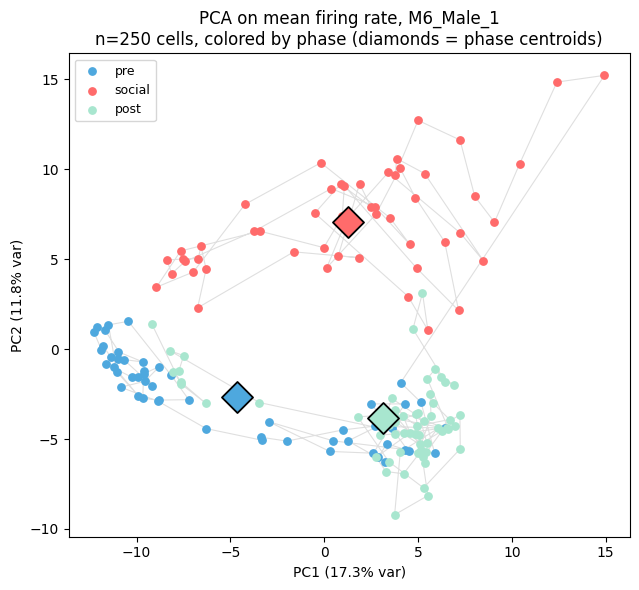

saved C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\fig_pca_M6_Male_1.png PC1+PC2 explain 29.2% of variance


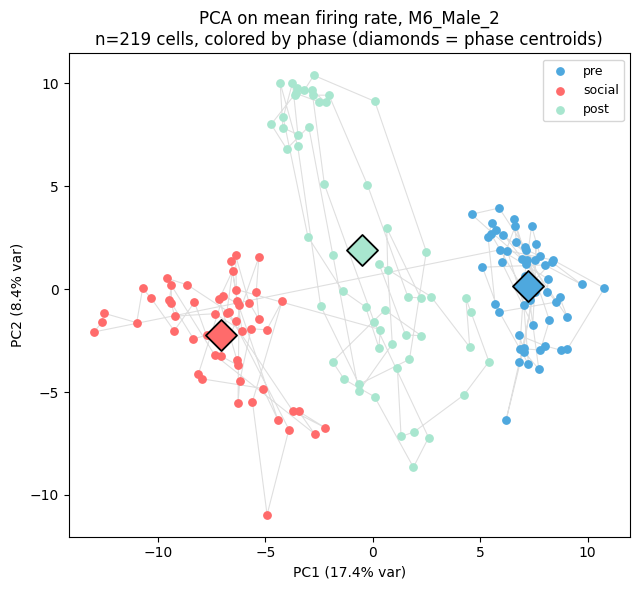

saved C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\fig_pca_M6_Male_2.png PC1+PC2 explain 25.8% of variance


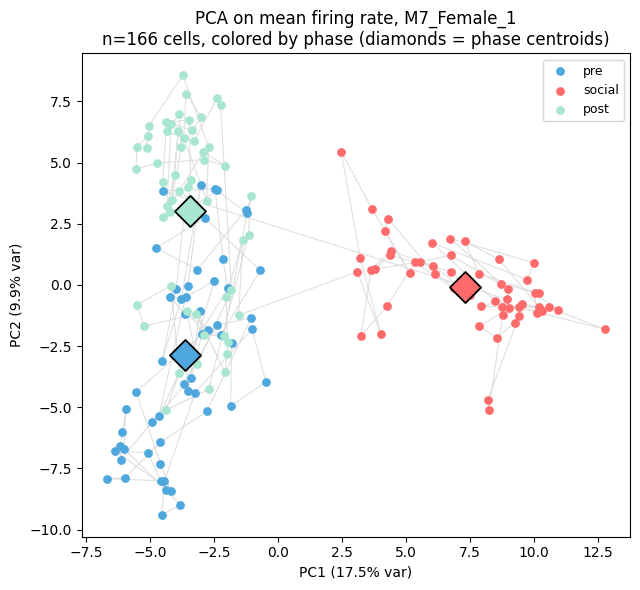

saved C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\fig_pca_M7_Female_1.png PC1+PC2 explain 27.4% of variance


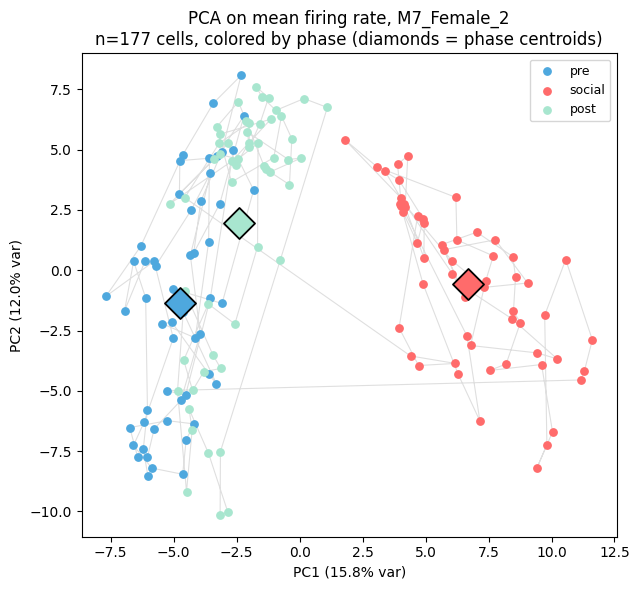

saved C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\fig_pca_M7_Female_2.png PC1+PC2 explain 27.9% of variance


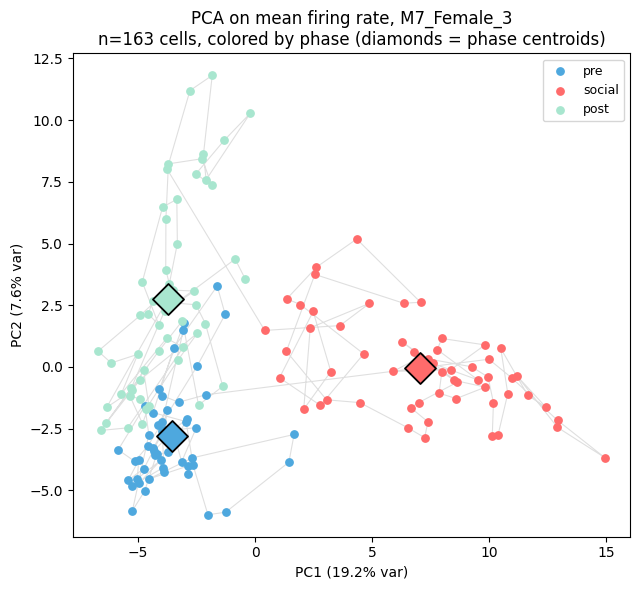

saved C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\fig_pca_M7_Female_3.png PC1+PC2 explain 26.8% of variance


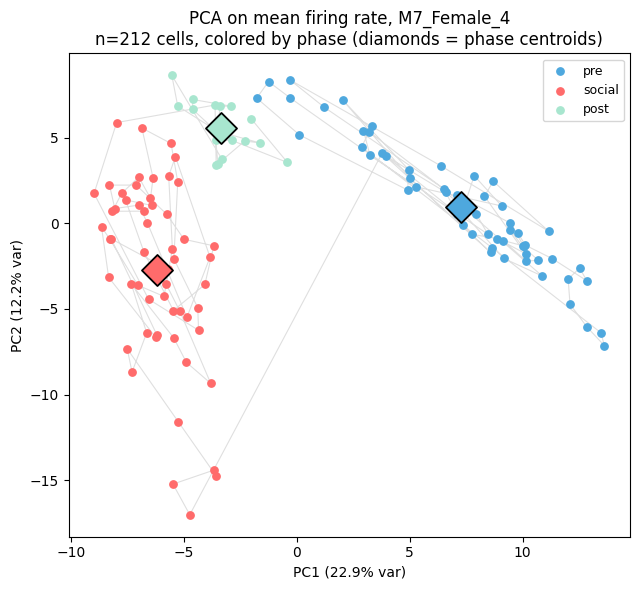

saved C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\fig_pca_M7_Female_4.png PC1+PC2 explain 35.1% of variance


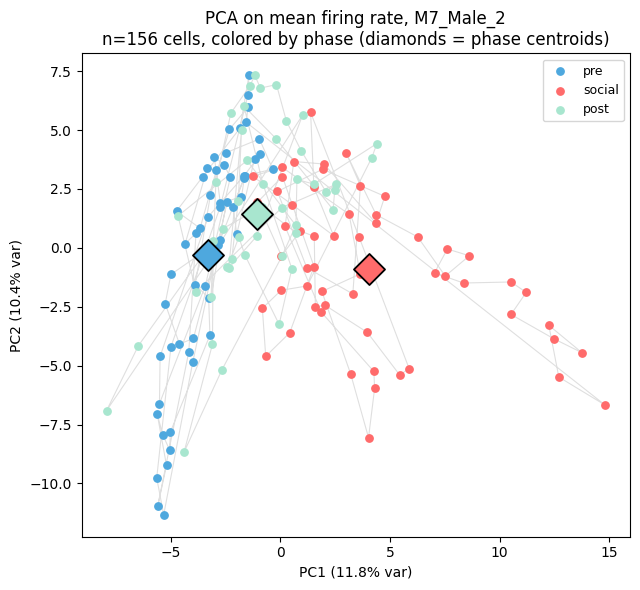

saved C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\fig_pca_M7_Male_2.png PC1+PC2 explain 22.2% of variance


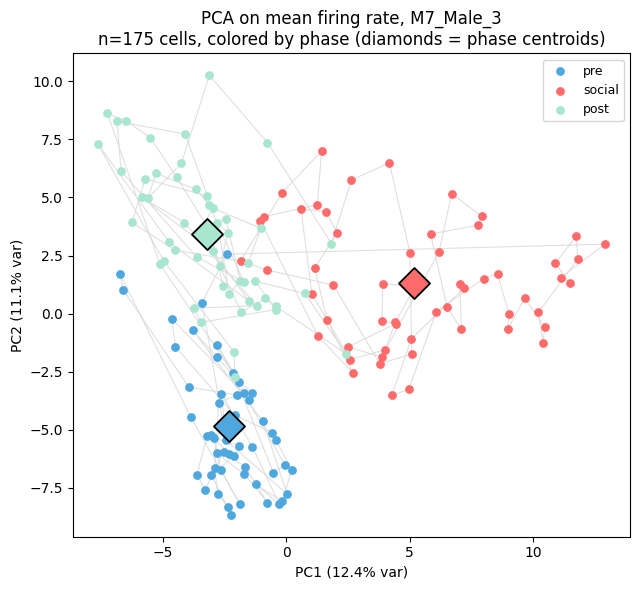

saved C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\fig_pca_M7_Male_3.png PC1+PC2 explain 23.5% of variance


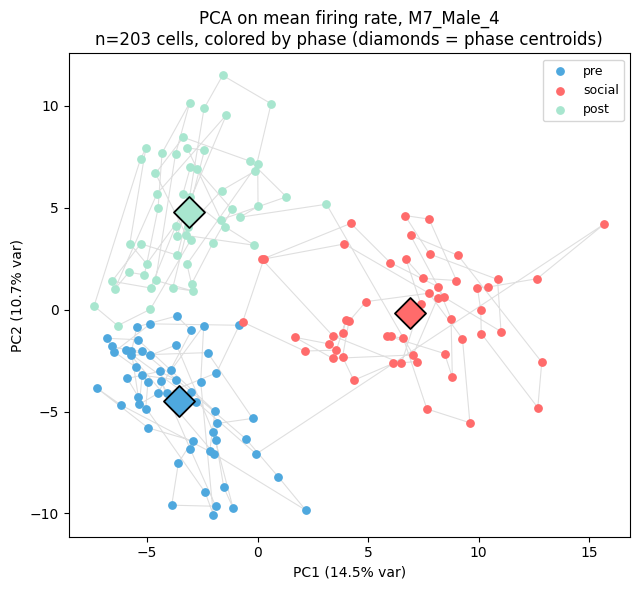

saved C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\fig_pca_M7_Male_4.png PC1+PC2 explain 25.2% of variance


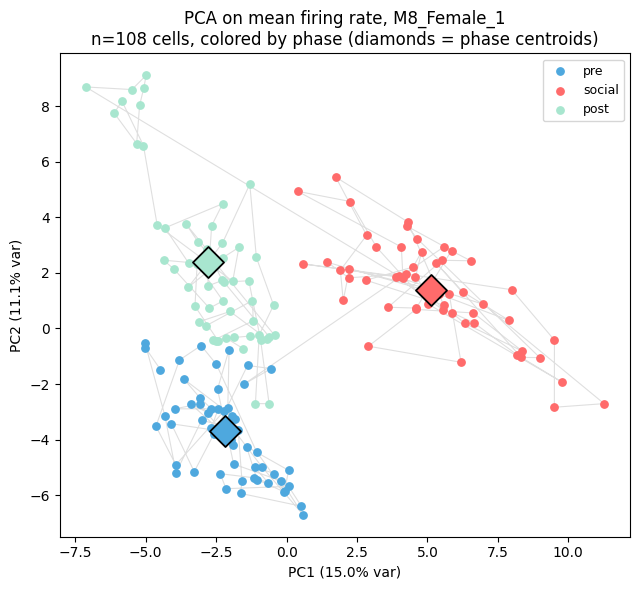

saved C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\fig_pca_M8_Female_1.png PC1+PC2 explain 26.2% of variance


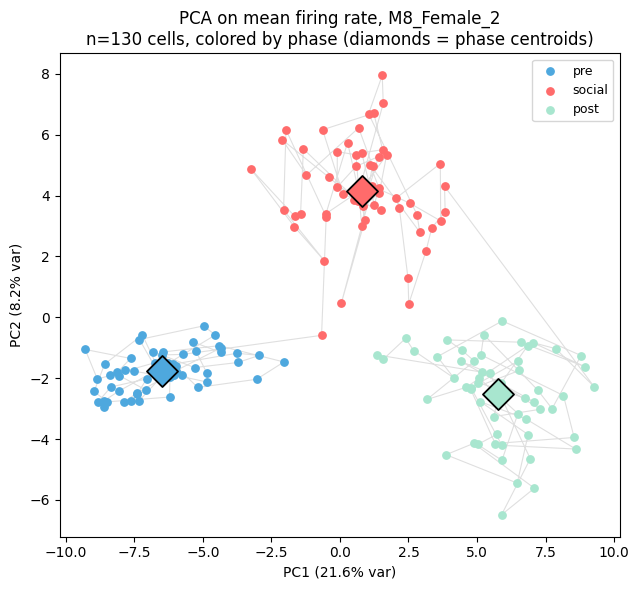

saved C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\fig_pca_M8_Female_2.png PC1+PC2 explain 29.8% of variance


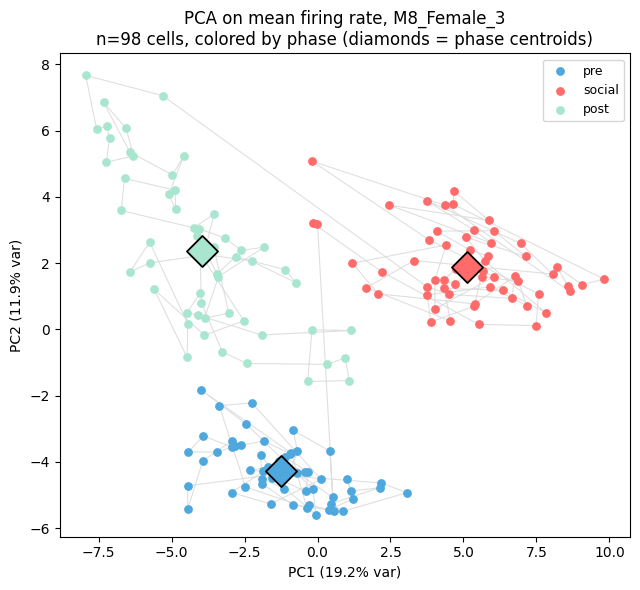

saved C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\fig_pca_M8_Female_3.png PC1+PC2 explain 31.1% of variance


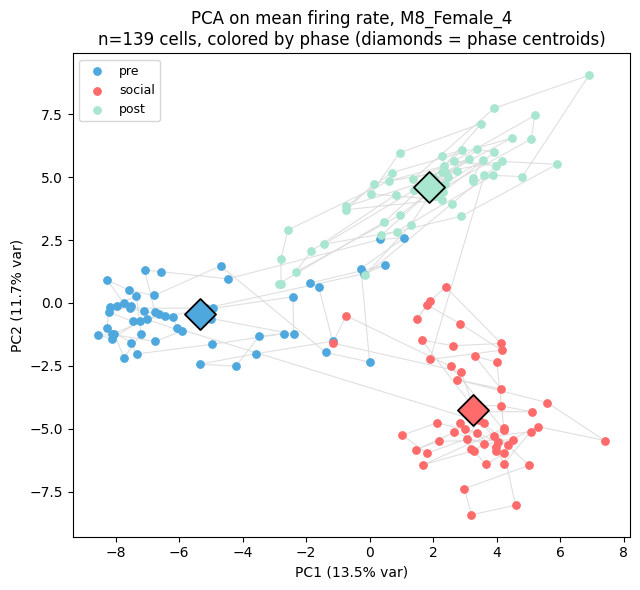

saved C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\fig_pca_M8_Female_4.png PC1+PC2 explain 25.2% of variance


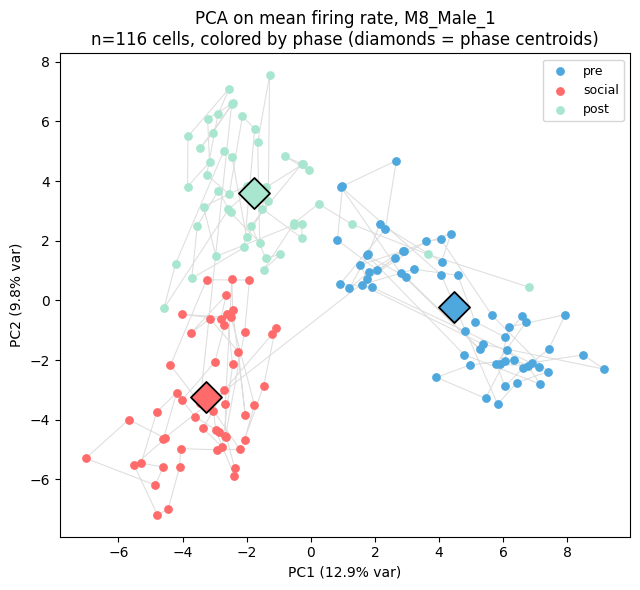

saved C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\fig_pca_M8_Male_1.png PC1+PC2 explain 22.7% of variance


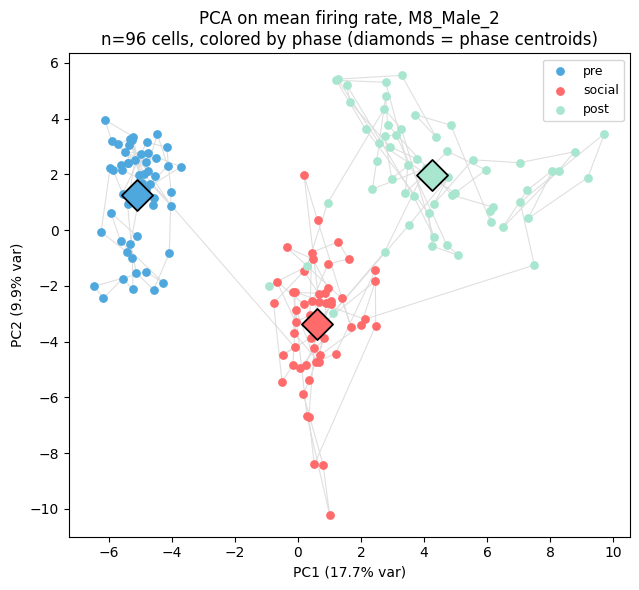

saved C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\fig_pca_M8_Male_2.png PC1+PC2 explain 27.6% of variance


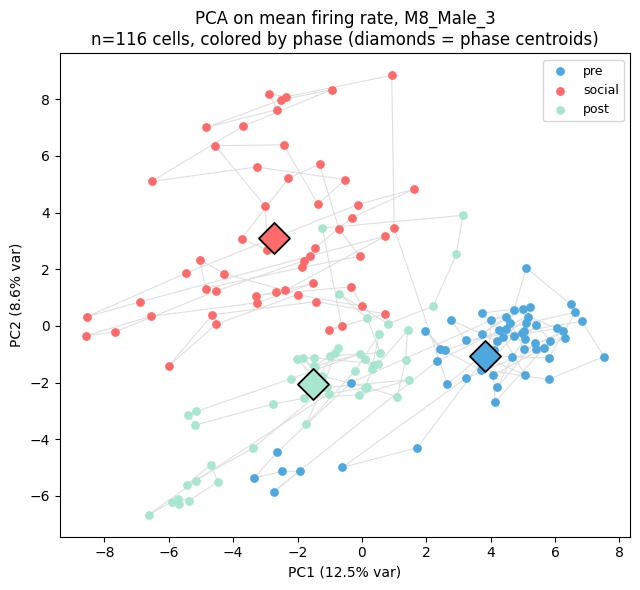

saved C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\fig_pca_M8_Male_3.png PC1+PC2 explain 21.1% of variance


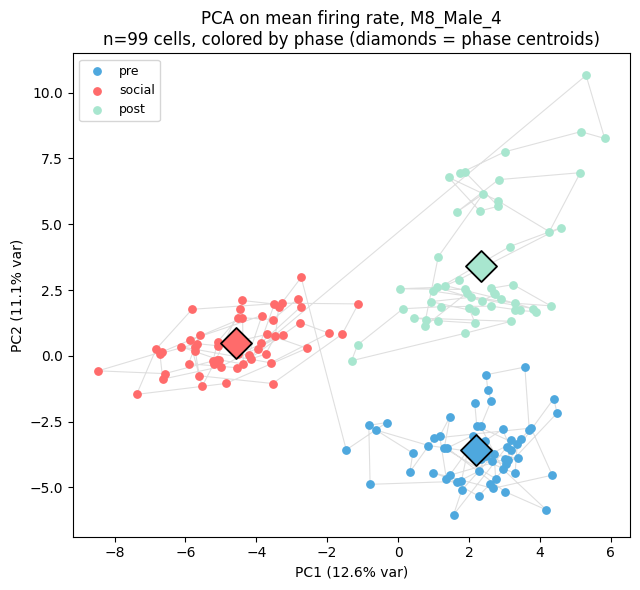

saved C:\Users\Sophie\Documents\University\Msc\Semester D\Neural Data Science 0970405\Technion-970405-Course-Final-Project\Daniel\final\figures_submission\fig_pca_M8_Male_4.png PC1+PC2 explain 23.7% of variance


In [12]:
from sklearn.decomposition import PCA

ALL_SESSIONS_PCA = [
    'M2_Female_1', 'M2_Female_2', 'M2_Female_3', 'M2_Female_4', 'M2_Male_1', 'M2_Male_2',
    'M2_Male_3', 'M3_Female_1', 'M3_Female_2', 'M3_Female_3', 'M3_Female_4', 'M3_Male_1',
    'M3_Male_2', 'M3_Male_3', 'M3_Male_4', 'M6_Female_1', 'M6_Male_1', 'M6_Male_2',
    'M7_Female_1', 'M7_Female_2', 'M7_Female_3', 'M7_Female_4', 'M7_Male_2', 'M7_Male_3',
    'M7_Male_4', 'M8_Female_1', 'M8_Female_2', 'M8_Female_3', 'M8_Female_4', 'M8_Male_1',
    'M8_Male_2', 'M8_Male_3', 'M8_Male_4',
]

PHASE_COLORS_PCA = {0: '#4ea8de', 1: '#ff6b6b', 2: '#a8e6cf'}
PHASE_NAMES_PCA = {0: 'pre', 1: 'social', 2: 'post'}


def _zscore_rows(sc):
    mu = sc.mean(axis=1, keepdims=True)
    sd = sc.std(axis=1, keepdims=True) + 1e-9
    return (sc - mu) / sd


for session_pca in ALL_SESSIONS_PCA:
    rec_pca = dl.load_session_record(session_pca, guard_s=GUARD_S, data_dir=DATA_DIR)
    if rec_pca is None:
        print(f'skip {session_pca}: could not detect phase edges')
        continue
    Y_pca, _ = feat_mod.get_channels(rec_pca, 'rate', feat_mod.CHANNEL_MODE_CELLS,
                                      subset_kind=feat_mod.NEURON_SUBSET_ALL)
    X_pca, y_raw_pca, tc_pca = feat_mod.make_rate_windows(
        Y_pca, rec_pca['t'], rec_pca['phase'], WIN_S, STEP_S, dl.FPS, keep_labels=(0, 1, 2))
    if len(y_raw_pca) < 10:
        print(f'skip {session_pca}: too few windows')
        continue

    Xz_pca = _zscore_rows(X_pca.T).T
    pca_model = PCA(n_components=2)
    coords_pca = pca_model.fit_transform(Xz_pca)
    var_exp = pca_model.explained_variance_ratio_

    fig_pca, ax_pca = plt.subplots(figsize=(6.5, 6))
    order_t_pca = np.argsort(tc_pca)
    ax_pca.plot(coords_pca[order_t_pca, 0], coords_pca[order_t_pca, 1],
                color='grey', alpha=0.25, lw=0.8, zorder=1)
    for lab_pca in [0, 1, 2]:
        mask_pca = y_raw_pca == lab_pca
        ax_pca.scatter(coords_pca[mask_pca, 0], coords_pca[mask_pca, 1],
                       color=PHASE_COLORS_PCA[lab_pca], s=28, zorder=2,
                       label=PHASE_NAMES_PCA[lab_pca])
        if mask_pca.sum() > 0:
            centroid_pca = coords_pca[mask_pca].mean(axis=0)
            ax_pca.scatter(*centroid_pca, color=PHASE_COLORS_PCA[lab_pca], s=250, marker='D',
                           edgecolor='black', linewidth=1.3, zorder=5)
    ax_pca.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}% var)')
    ax_pca.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}% var)')
    ax_pca.set_title(f'PCA on mean firing rate, {session_pca}\n'
                     f'n={Y_pca.shape[0]} cells, colored by phase (diamonds = phase centroids)')
    ax_pca.legend(fontsize=9, loc='best')
    fig_pca.tight_layout()
    out_pca = FIG_DIR / f'fig_pca_{session_pca}.png'
    fig_pca.savefig(out_pca, dpi=200, bbox_inches='tight')
    plt.show()
    plt.close(fig_pca)
    print('saved', out_pca, f'PC1+PC2 explain {var_exp.sum()*100:.1f}% of variance')
